# 태양광 발전소 발전량 예측 (LSTM, Transformer(encoder-only))

[Notion |  https://www.notion.so/ryudoyeon/PV_Plant-Power-26561f7ccc3f802d875af29b7a099e65?source=copy_link]

## 1. Object Setting

> **LSTM**과 **Transforme**r를 멀티 모델로 구현  
> 결과: 한 station의 power 혹은 모든 station의 각각의 power  
> 멀티 모델로 여러 station을 모두 학습하여 결과 냄  
> 두 모델의 성능 비교 (Transformer)가 우세하도록….  

목표

- 태양광 발전소의 발전량(power)을 NWP + LMD 기상 데이터와 meta 데이터를 활용해 예측
- 글로벌 모델: 여러 발전소를 동시에 학습해 공통 패턴 + 개별 특성을 함께 반영
- 시계열 데이터: 15분 단위 **2018년 08월 15일 16:00:00 - 2019년 06월 13일 15:45:00**

In [1]:
import pandas as pd
import numpy as np
import folium
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import math
from torch.utils.data import DataLoader

from models.PVPlant_LSTM import PVPlantLSTM
from models.PVPlant_Transformer import PVPlantTransformer

from utils.evaluate_metrics import evaluate, metrics
from utils.train import SeqDataset, train
from plots.plot_prediction import plot_station_with_predictions

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## 2. Data Curation & 3. Data Inspection

### metadata

1. 열 설명
    - Station_ID: 발전소의 고유 식별자   
    - Capacity: 발전소의 설치 용량 (태양광 시스템이 최대 출력할 수 있는 정격 전력)   
    - PV_Technology: 사용된 태양광 패널 기술 종류   
    - Panel_Size: 태양광 모듈 1장의 크기
    - Module: 사용된 태양광 모듈의 모델명 또는 제조사
    - Inverters: 사용된 인버터 종류 및 개수
    - Layout: 패널 배치 방식
    - Panel_Number: 설치된 패널의 총 개수
    - Array_Tilt: 패널의 기울기 각도
    - Pyranometer: 설치 여부 또는 모델명
    - Longtitude: 발전소 경도 좌표
    - Latitude: 발전소 위도 좌표

2. 각 열 시각화
    - 수치형 / 범주형 변수 존재
    - Preprocessing에서 임베딩 필요
    - 위/경도 - 지도 시각화
        - 스케일링 or 지역 군집화
        - 비슷한 중국 지역 밀집도 확인
3. 이상치, 결측치 확인
    - 건물 특성 정보 데이터라 10행
    - 이상치 / 결측치 존재하지 않음

In [2]:
metadata = pd.read_csv("PVODdatasets_v1.0/metadata.csv")
metadata

,Station_ID,Capacity,PV_Technology,Panel_Size,Module,Inverters,Layout,Panel_Number,Array_Tilt,Pyranometer,Longitude,Latitude
0,station00,6600,Poly-Si,1.62360,products types:LW255(29)P1640×990\nPmax:255 Wp...,products types:NSG-500K3TL\nMax. DC input:560 ...,modules per string:20\nstrings per inverter:96,26000,South 33°,GHI: \nproducts types: TBQ-2\nmeasurement accu...,114.951390,38.047780
1,station01,20000,Poly-Si,1.66350,products types:LW6P60-270\nPmax:270 Wp\nVmpp:3...,products types:TC500KH\nMax. DC input:618 kW\n...,modules per string:22\nstrings per inverter:128,74000,South 33°,GHI: \nproducts types: TBQ-2\nmeasurement accu...,117.457220,38.183060
2,station02,17000,Mono-Si,1.63680,products types:RSM60-6-285M\nPmax:285 Wp\nVmpp...,products types:SG50KTL-M\nMax. DC input:-\nMax...,modules per string:22\nstrings per inverter:8,64064,South 29°,GHI: \nproducts types: TBQ-2\nmeasurement accu...,114.198870,38.057280
3,station03,20000,Poly-Si,1.62000,products types:HTMP265P4-60\nPmax:265 Wp\nVmpp...,products types:PVL-L1000E\nMax. DC input:-\nMa...,modules per string:22\nstrings per inverter:16,75460,South 33°,GHI: \nproducts types: TBQ-2L\nmeasurement acc...,114.114940,38.109560
4,station04,20000,Poly-Si,1.63680,products types:YL265P-29b\nPmax:265 Wp\nVmpp:3...,products types:SG1000\nMax. DC input:560 kW\nM...,modules per string:22\nstrings per inverter:86,75680,South 37°,GHI: \nproducts types: TBQ-2\nmeasurement accu...,114.867670,39.515500
5,station05,35000,Poly-Si,1.63515,products types:LR6-60-305M\nPmax:305 Wp\nVmpp:...,products types:SG1250UD\nMax. DC input:618 kW\...,modules per string:22\nstrings per inverter:160,114972,South 33°,GHI: \nproducts types: TBQ-2\nmeasurement accu...,114.123600,38.235500
6,station06,15000,Poly-Si,1.63350,products types:JAP60S01-270/SC\nPmax:270 Wp\nV...,products types:SG50KTL-M\nMax. DC input:-\nMax...,modules per string:24\nstrings per inverter:8,56608,South 34°,GHI: \nproducts types: TBQ-2\nmeasurement accu...,114.548410,36.898910
7,station07,20000,Poly-Si,1.63350,products types:YL250P-29b\nPmax:250 Wp\nVmpp:2...,products types:TC500KH\nMax. DC input:618 kW\n...,modules per string:20\nstrings per inverter:100,80000,South 31°,GHI: \nproducts types: TBQ-2L\nmeasurement acc...,113.641870,36.644030
8,station08,20000,Poly-Si,1.63350,products types:YL265C-30b\nPmax:265 Wp\nVmpp:3...,products types:SUN2000-40KTL\nMax. DC input: 4...,modules per string:22\nstrings per inverter:5,78042,South 33°,GHI: \nproducts types: TBQ-2\nmeasurement accu...,113.899990,36.707610
9,station09,20000,Poly-Si,1.61370,products types:YL265P-29B-265W\nPmax:265 Wp\nV...,products types:GSL0630T\nMax. DC input:690 kW\...,modules per string:24\nstrings per inverter:128,84480,South 31°,GHI: \nproducts types: TBQ-2\nmeasurement accu...,115.059855,38.731417


1. 열 목록

In [3]:
metadata.columns

Index(['Station_ID', 'Capacity', 'PV_Technology', 'Panel_Size', 'Module',
       'Inverters', 'Layout', 'Panel_Number', 'Array_Tilt', 'Pyranometer',
       'Longitude', 'Latitude'],
      dtype='object')

2. 각 열 시각화

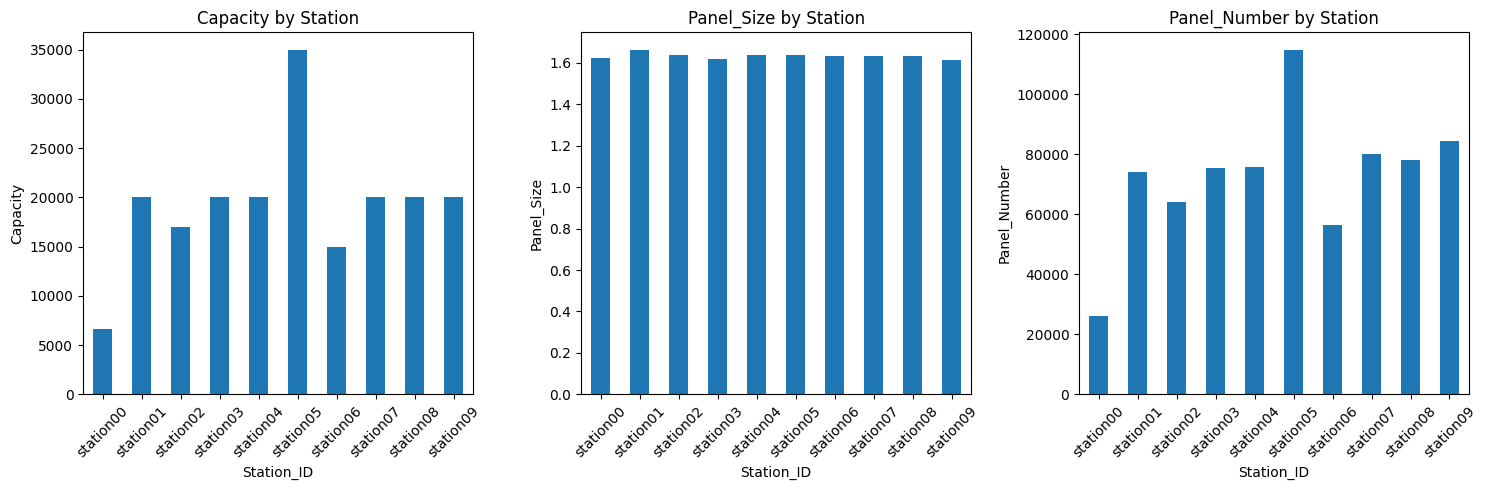

In [4]:
# (1) 수치형 열 Bar chart

num_cols = ['Capacity', 'Panel_Size', 'Panel_Number']
stations = metadata['Station_ID'].nunique()

# subplot 크기 정의
fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 5))

for i, col in enumerate(num_cols):
    ax = axes[i]
    values = metadata.groupby('Station_ID')[col].mean()
    values.plot(kind='bar', ax=ax)
    ax.set_title(f'{col} by Station')
    ax.set_xlabel('Station_ID')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [5]:
# (2) 범주형 열 개수, 빈도수 파악
cat_cols = ['PV_Technology', 'Inverters', 'Array_Tilt', 'Pyranometer']

for col in cat_cols:
    print(f"Column: {col}")
    print(metadata[col].value_counts())
    print("\n")

# Module, Layout: 10개가 모두 다름 - 학습 시 제외함
# 나머지는 추후 인코딩 or 임베딩 계획

Column: PV_Technology
PV_Technology
Poly-Si    9
Mono-Si    1
Name: count, dtype: int64


Column: Inverters
Inverters
products types:TC500KH\nMax. DC input:618 kW\nMax. DC voltage: 1000 V\nMax. DC current: 1344 A\nRated power: 500 kW\nmanufacturer:tbeapower                                                   2
products types:SG50KTL-M\nMax. DC input:-\nMax. DC voltage: 1100 V\nMax. DC current: 100 A\nRated power: 55 kW\nmanufacturer:sungrowpower                                                     2
products types:NSG-500K3TL\nMax. DC input:560 kW\nMax. DC voltage: 1000 V\nMax. DC current: 1120 A\nRated power: 500 kW\nmanufacturer:ZOF new energy                                          1
products types:PVL-L1000E\nMax. DC input:-\nMax. DC voltage: 1000 V\nMax. DC current: 1344 A\nRated power: 1000 kW\nmanufacturer:Toshiba Mitsubishi-Electric Industrial System Corporation    1
products types:SG1000\nMax. DC input:560 kW\nMax. DC voltage: 1000 V\nMax. DC current: 1220 A\nRated power: 1000 k

In [6]:
# (3) station 지도 시각화

# 지도 초기화 (중심: 평균 좌표)
m = folium.Map(location=[metadata["Latitude"].mean(), metadata["Longitude"].mean()], zoom_start=7)

# 마커 추가
for _, row in metadata.iterrows():
    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        popup=f"Station: {row['Station_ID']}"
    ).add_to(m)

m

3. 이상치 / 결측치 확인
    - 실제 발전소 특성 정보, 10개 밖에 안 됨
    - 이상치 / 결측치 존재하지 않음

In [7]:
# 결측치 확인
print(metadata.isnull().sum())

Station_ID       0
Capacity         0
PV_Technology    0
Panel_Size       0
Module           0
Inverters        0
Layout           0
Panel_Number     0
Array_Tilt       0
Pyranometer      0
Longitude        0
Latitude         0
dtype: int64


### station 데이터

1. 열 설명
    - date_time: timstamp   
**NWP (Numerical Weather Prediction, 수치예보 모델 출력 값)**   
    - nwp_globalirrad: Global Irradiance (태양이 지표면에 도달하는 총 일사량 (W/m2))
    - nwp_directirrad: Direct Irradiance (태양에서 직접 도달하는 일사 성분 (W/m2))
    - nwp_temperature: 기온, NWP에서 예측된 값
    - nwp_humidity: 상대습도, NWP에서 예측된 값
    - nwp_windspeed: 풍속, NWP 예보 값
    - nwp_winddirection: 풍향, NWP 예보 값
    - nwp_pressure: 기압, NWP 예보 값   
**LMD (Local Meteorological Data, 현장 기상 관측 데이터)**   
    - lmd_totalirrad: 총 일사량(Global Irradiance), 현장 측정 값   
    - lmd_diffuseirrad: 산란일사량(Diffuse Irradiance), 구름/대기 산란을 통해 도달하는 성분
    - lmd_temperature: 기온, 현장 기상 센서 측정 값
    - lmd_pressure: 기압, 현장 기상 센서 측정 값
    - lmd_winddirection: 풍향, 현장 측정 값
    - lmd_windspeed: 풍속, 현장 측정 값   
**발전소 성능**   
    - power: 실제 발전소의 전력 출력   

2. 예측값: power
3. 각 기상변수 vs power 시각화
    - 발전소별 데이터 분포 확인
    - 그래프
    - 히트맵 (기상 변수와 발전량 간의 기본 상관 관계 확인)
4. 발전소별 데이터 개수 균형, 운영 기간 체크
5. 이상치, 결측치 확인
    - 평균, 중앙값, 이상치 등등 확인

In [8]:
stations = pd.DataFrame()
for i in range(10):
    df = pd.read_csv(f"PVODdatasets_v1.0/station0{i}.csv")
    df["Station_ID"] = f"station{i:02d}"
    stations = pd.concat([stations, df], ignore_index=True)
# 열 순서 변경 Station_ID 맨 앞으로
stations = stations[["Station_ID"] + [col for col in stations.columns if col != "Station_ID"]]
# Station_ID, date_time으로 정렬
stations = stations.sort_values(by=["Station_ID", "date_time"]).reset_index(drop=True)
stations

,Station_ID,date_time,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_winddirection,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,lmd_pressure,lmd_winddirection,lmd_windspeed,power
0,station00,2018-08-15 16:00:00,0.0,0.0,22.78,96.85,4.28,339.41,1007.27,0.0,0.0,25.900000,1006.299988,353.0,1.1,0.0
1,station00,2018-08-15 16:15:00,0.0,0.0,22.75,96.91,4.30,337.27,1007.27,0.0,0.0,25.900000,1006.200012,330.0,0.9,0.0
2,station00,2018-08-15 16:30:00,0.0,0.0,22.71,96.95,4.28,334.47,1007.48,0.0,0.0,25.799999,1006.299988,1.0,1.9,0.0
3,station00,2018-08-15 16:45:00,0.0,0.0,22.64,97.12,4.28,331.52,1007.39,0.0,0.0,25.600000,1006.299988,309.0,0.4,0.0
4,station00,2018-08-15 17:00:00,0.0,0.0,22.57,97.15,4.33,329.78,1007.09,0.0,0.0,25.700001,1006.299988,335.0,1.6,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271963,station09,2019-06-13 14:45:00,0.0,0.0,25.60,59.45,2.92,11.18,999.82,0.0,0.0,21.400000,998.299988,111.0,0.0,0.0
271964,station09,2019-06-13 15:00:00,0.0,0.0,25.35,60.53,2.90,4.73,999.92,0.0,0.0,21.299999,998.400024,181.0,0.4,0.0
271965,station09,2019-06-13 15:15:00,0.0,0.0,25.11,61.55,2.95,358.79,1000.01,0.0,0.0,22.400000,998.299988,346.0,0.0,0.0
271966,station09,2019-06-13 15:30:00,0.0,0.0,24.88,62.46,3.03,353.39,1000.12,0.0,0.0,22.000000,998.400024,141.0,0.0,0.0


1. 열 목록

In [9]:
stations.columns

Index(['Station_ID', 'date_time', 'nwp_globalirrad', 'nwp_directirrad',
       'nwp_temperature', 'nwp_humidity', 'nwp_windspeed', 'nwp_winddirection',
       'nwp_pressure', 'lmd_totalirrad', 'lmd_diffuseirrad', 'lmd_temperature',
       'lmd_pressure', 'lmd_winddirection', 'lmd_windspeed', 'power'],
      dtype='object')

2. 예측값: power

- 각 발전소마다 시계열 범위가 다름을 확인
- 글로벌 모델 학습 시 각 발전소마다 가진 데이터 기간만큼 학습하도록 반영

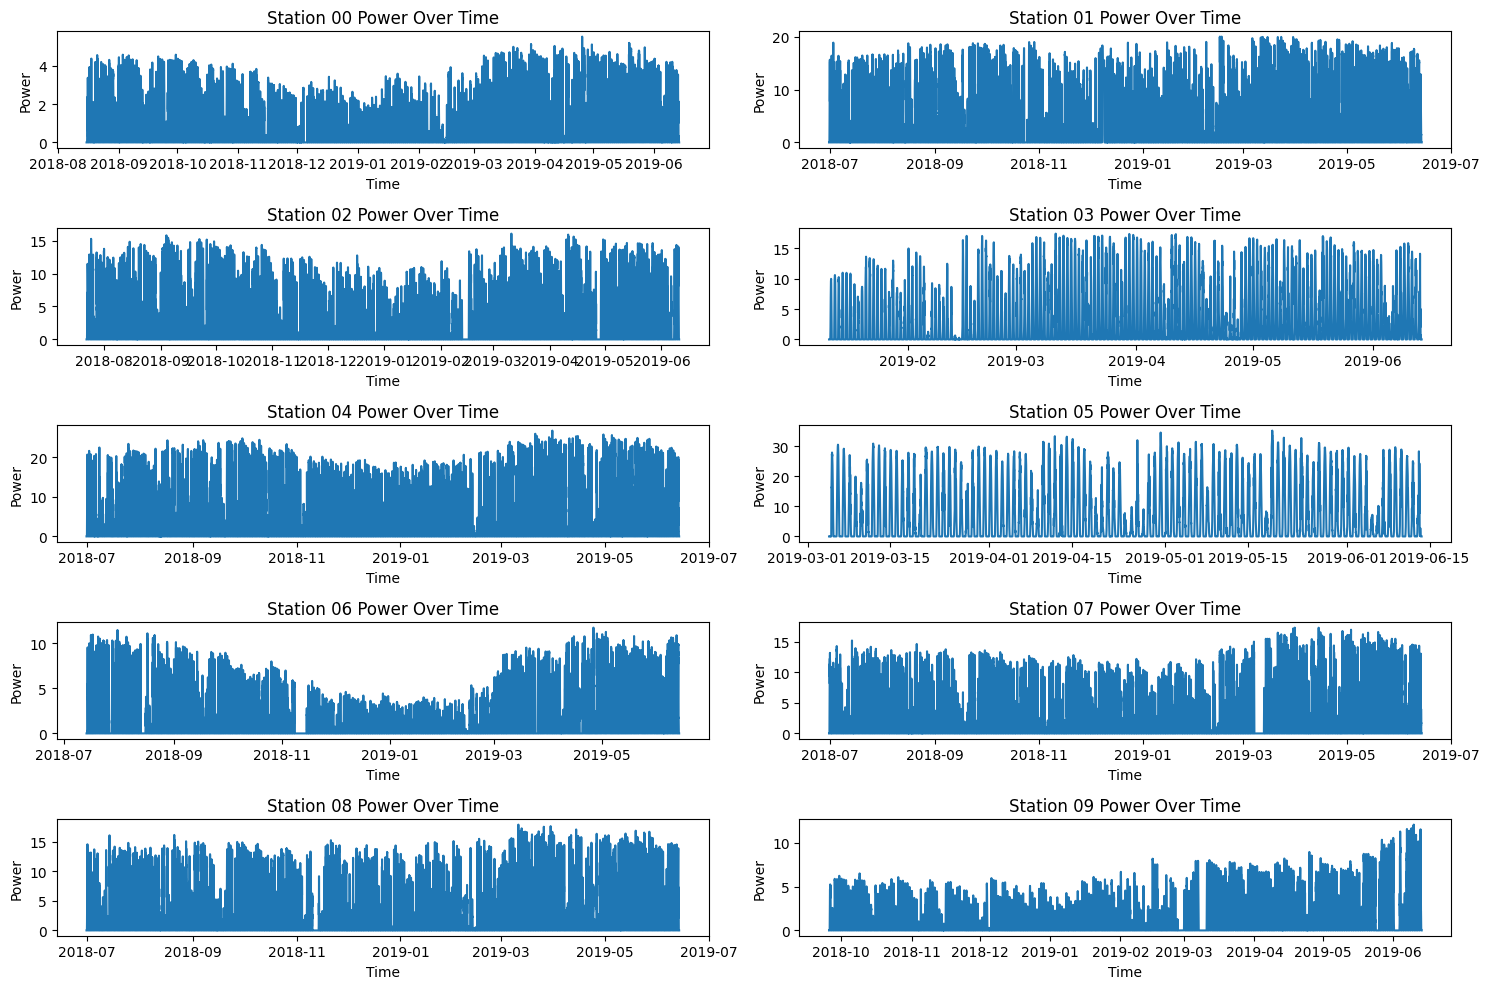

In [10]:
# 각 발전소별 power 시계열 시각화
plt.figure(figsize=(15, 10))
for i in range(10):
    plt.subplot(5, 2, i+1)
    station_data = stations[stations['Station_ID'] == f'station{i:02d}']
    plt.plot(pd.to_datetime(station_data['date_time']), station_data['power'])
    plt.title(f'Station {i:02d} Power Over Time')
    plt.xlabel('Time')
    plt.ylabel('Power')
    plt.tight_layout()

3. 각 기상변수 vs power 시각화

In [11]:
# 각 기상변수 vs power 시각화 # 각 발전소마다 따로 시각화
# 그래프: 발전소 수 x 기상변수 수
weather_cols = [col for col in stations.columns if col not in ['Station_ID', 'date_time', 'power']]
def plot_weather_vs_power(station_id):
    station_data = stations[stations['Station_ID'] == station_id]
    ncols = 3  # 한 줄에 3개씩
    nrows = math.ceil(len(weather_cols) / ncols)
    print(f"Plotting for {station_id}")
    plt.figure(figsize=(6*ncols, 4*nrows))  # 전체 크기 조정
    for j, col in enumerate(weather_cols):
        ax = plt.subplot(nrows, ncols, j + 1)
        ax.scatter(station_data[col], station_data['power'], alpha=0.5)
        ax.set_title(f'{station_id} - {col} vs Power')
        ax.set_xlabel(col)
        ax.set_ylabel('Power')
    # plt.suptitle(f'Weather Variables vs Power for {station_id}', fontsize=16)
    plt.tight_layout()
    plt.show()

In [12]:
# for i in range(10):
#     plot_weather_vs_power(f'station{i:02d}')

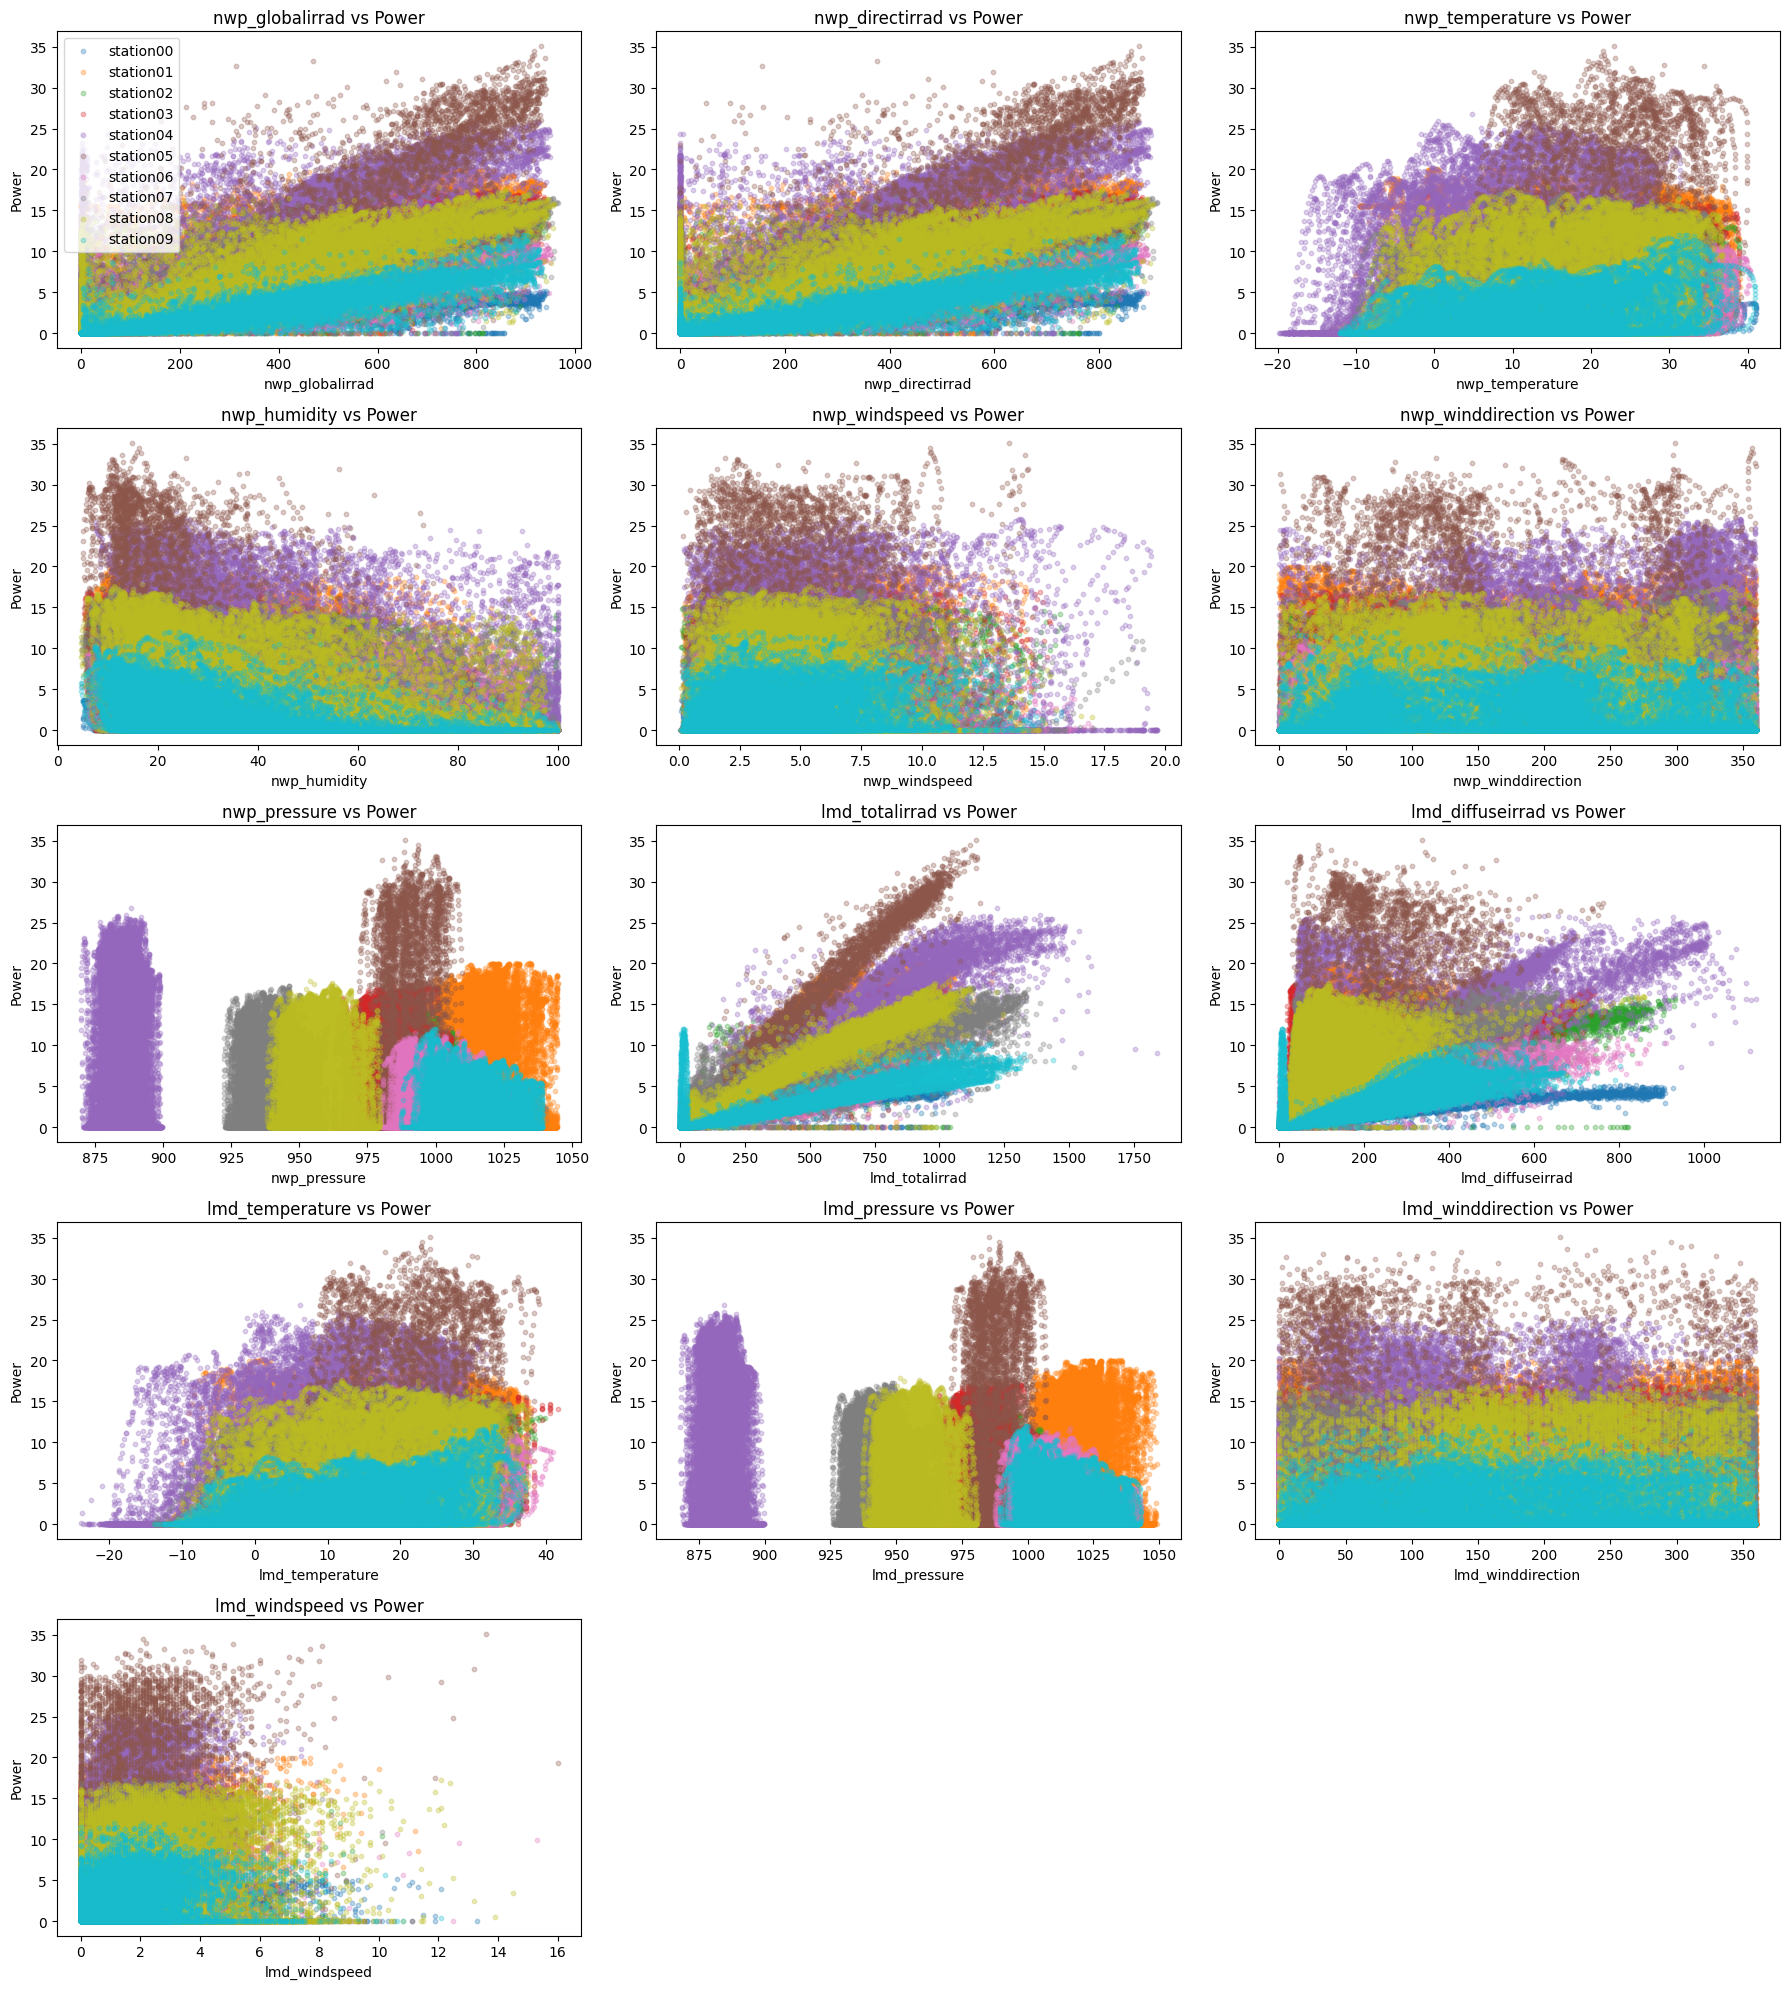

In [13]:
weather_cols = [col for col in stations.columns if col not in ['Station_ID', 'date_time', 'power']]

ncols = 3
nrows = math.ceil(len(weather_cols) / ncols)

plt.figure(figsize=(6*ncols, 4*nrows))

for j, col in enumerate(weather_cols):
    ax = plt.subplot(nrows, ncols, j + 1)
    for sid, group in stations.groupby('Station_ID'):
        ax.scatter(group[col], group['power'], alpha=0.3, label=sid, s=10)
    ax.set_title(f'{col} vs Power')
    ax.set_xlabel(col)
    ax.set_ylabel('Power')
    if j == 0:  # 첫 번째 subplot에만 범례
        ax.legend()

plt.tight_layout()
plt.show()


In [14]:
# # 상관관계 히트맵
# #    기상 변수와 발전량 간의 기본 상관 관계 확인

# # 발전소 ID 목록
# station_ids = sorted(stations['Station_ID'].unique())

# # 발전소별로 상관관계 계산
# for sid in station_ids:
#     station_data = stations[stations['Station_ID'] == sid]
    
#     # 기상변수 + power만 선택
#     corr_df = station_data[weather_cols + ['power']]
    
#     # 상관계수 계산
#     corr_matrix = corr_df.corr()
    
#     # power와의 상관계수만 추출 (행: 변수, 열: power)
#     corr_with_power = corr_matrix[['power']].drop('power')
    
#     # 히트맵 시각화
#     plt.figure(figsize=(6, len(weather_cols)*0.4))
#     sns.heatmap(corr_with_power, annot=True, cmap="coolwarm", center=0)
#     plt.title(f"{sid} - Weather vs Power Correlation")
#     plt.show()

# # 상관 관계가 낮은 변수들도 학습에 포함 - 비선형 관계나 변수 상호작용을 위해서 
# # 그러나 모델 학습 후 Feature importance 확인해서 기여도가 낮을 시 제거
# #    Shapley values / permutation importance / attention score로 변수 기여도 확인

4. 발전소별 데이터 개수 균형, 운영 기간 체크

In [15]:
# 각 발전소별 시계열 데이터 범위 확인
for i in range(10):
    station_data = stations[stations['Station_ID'] == f'station{i:02d}']
    min_date = pd.to_datetime(station_data['date_time']).min()
    max_date = pd.to_datetime(station_data['date_time']).max()
    print(f'Station {i:02d}: {min_date} to {max_date}, Total records: {len(station_data)}')

# 우선, 범위 합집합 모델 학습 예정
# 글로벌 모델 시 각 발전소 시계열 데이터 범위마다 구별, 학습/검증/테스트 분할, 보간 등 전처리 계획

Station 00: 2018-08-15 16:00:00 to 2019-06-13 15:45:00, Total records: 28896
Station 01: 2018-06-30 16:00:00 to 2019-06-13 15:45:00, Total records: 33408
Station 02: 2018-07-22 16:00:00 to 2019-06-10 15:45:00, Total records: 30432
Station 03: 2019-01-11 16:00:00 to 2019-06-13 15:45:00, Total records: 14688
Station 04: 2018-06-30 16:00:00 to 2019-06-13 15:45:00, Total records: 33408
Station 05: 2019-03-04 16:00:00 to 2019-06-13 15:45:00, Total records: 9696
Station 06: 2018-07-13 16:00:00 to 2019-06-13 15:45:00, Total records: 31104
Station 07: 2018-06-30 16:00:00 to 2019-06-13 15:45:00, Total records: 32928
Station 08: 2018-06-30 16:00:00 to 2019-06-13 15:45:00, Total records: 33120
Station 09: 2018-09-25 16:00:00 to 2019-06-13 15:45:00, Total records: 24288


5. 이상치, 결측치 확인

In [16]:
# 각 발전소별 열 결측치 확인
for i in range(10):
    station_data = stations[stations['Station_ID'] == f'station{i:02d}']
    print(f"Station {i:02d} Missing Values:")
    print(station_data.isnull().sum())
    print("\n")


Station 00 Missing Values:
Station_ID           0
date_time            0
nwp_globalirrad      0
nwp_directirrad      0
nwp_temperature      0
nwp_humidity         0
nwp_windspeed        0
nwp_winddirection    0
nwp_pressure         0
lmd_totalirrad       0
lmd_diffuseirrad     0
lmd_temperature      0
lmd_pressure         0
lmd_winddirection    0
lmd_windspeed        0
power                0
dtype: int64


Station 01 Missing Values:
Station_ID           0
date_time            0
nwp_globalirrad      0
nwp_directirrad      0
nwp_temperature      0
nwp_humidity         0
nwp_windspeed        0
nwp_winddirection    0
nwp_pressure         0
lmd_totalirrad       0
lmd_diffuseirrad     0
lmd_temperature      0
lmd_pressure         0
lmd_winddirection    0
lmd_windspeed        0
power                0
dtype: int64


Station 02 Missing Values:
Station_ID           0
date_time            0
nwp_globalirrad      0
nwp_directirrad      0
nwp_temperature      0
nwp_humidity         0
nwp_windspeed  

In [17]:
for i in range(10):
    print(f"Station {i:02d} Descriptive Statistics:")
    print(station_data.describe())
    print("\n")

Station 00 Descriptive Statistics:
       nwp_globalirrad  nwp_directirrad  nwp_temperature  nwp_humidity  \
count     24288.000000     24288.000000     24288.000000  24288.000000   
mean        168.616393       148.487672         9.149694     35.288623   
std         245.244499       224.780828        10.268703     18.067687   
min           0.000000         0.000000       -12.010000      4.640000   
25%           0.000000         0.000000         0.860000     22.040000   
50%           0.000000         0.000000         8.240000     31.760000   
75%         316.267500       271.505000        16.260000     43.710000   
max         931.560000       874.590000        40.980000     99.930000   

       nwp_windspeed  nwp_winddirection  nwp_pressure  lmd_totalirrad  \
count   24288.000000       24288.000000  24288.000000    24288.000000   
mean        3.463507         189.689110   1015.457260      201.963112   
std         2.082610         113.733165      9.919514      323.603158   
min   

In [18]:
# # 각 열별 이상치 Box plot (발전소 다른 색)
# # weather_cols 사용
# for col in weather_cols:
#     plt.figure(figsize=(10, 6))
#     sns.boxplot(x='Station_ID', y=col, data=stations)
#     plt.title(f'Box Plot of {col} by Station')
#     plt.xlabel('Station_ID')
#     plt.ylabel(col)
#     plt.xticks(rotation=45)
#     plt.show()

# # 이상치 처리 계획
# # IQR, Z-score 등 통계적 방법 활용 예정
# # 이상치 큰 변수
# # nwp_globalirrad, nwp_directirrad, nwp_windspeed, nwp_windspeed, lmd_totalirrad, lmd_diffuseirrad, lmd_windspeed

## 4. Data Preprocessing

### Metadata

1. 수치형 변수 → 스케일링
2. 범주형 변수 → one-hot 임베딩
3. 위치 → 스케일링 or 지역 군집화
4. station_id 임베딩

- train/valid/test 분할 필요 없음

In [19]:
# Module, Layout: 10개가 모두 다름 - 학습 시 제외함
metadata = metadata.drop(columns=['Module', 'Layout'])

1. 수치형 변수 -> 스케일링

In [20]:
# 수치형 메타데이터
# num_cols = ['Capacity', 'Panel_Size', 'Panel_Number']
# 이상치 / 결측치 존재하지 않음
# 단순 스케일링만 진행

# Capacity, Panel_Number: StandardScaler # 이상치 존재 가능성 있음
# Panel_Size: MinMaxScaler # 값이 다 비슷함

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

for col in ['Capacity', 'Panel_Number']:
    metadata[col] = scaler_std.fit_transform(metadata[[col]])
metadata['Panel_Size'] = scaler_mm.fit_transform(metadata[['Panel_Size']])

In [21]:
# 범주형 메타데이터
# cat_cols = ['PV_Technology', 'Inverters', 'Array_Tilt', 'Pyranometer']
# 데이터가 10개 밖에 안 되므로 전부 원-핫 인코딩

metadata = pd.get_dummies(metadata, columns=cat_cols, drop_first=True)
for col in metadata.columns:
    if metadata[col].dtype == bool:
        metadata[col] = metadata[col].astype(int)

# 스케일링할 숫자만 변환
for col in ['Latitude', 'Longitude']:
    metadata[col] = scaler_mm.fit_transform(metadata[[col]])

metadata 전처리 완료

### station data

1. NWP / LMD / Power 정렬 및 시간 동기화
2. Feature engineering
    - 날짜 관련 정보 추가
3. train / valid / test 분할
    - train
    - valid
    - test
4. 이상치 확인 후 결측치로 변환
5. 결측지 확인 후 보정
    - 보간, 앞 뒤
6. 풍향, 시간 → sin/cos 변환
7. X, y 분할
8. 스케일링
    - train으로만 fit → valid, test transform
9. 타겟 로그 변환 (선택)
10. 슬라이딩 윈도우 생성 
    - input_window:
    - output_window:

1. 발전소별 시계열 데이터 정렬

In [22]:
# 정렬 및 시간 동기화
# 아직은 NWP, LMD, power 모두 함께 수행

def sort_by_station_and_time(df) -> pd.DataFrame:
    """
    Function: sort_by_station_and_time
        - 발전소 ID와 시간에 따라 데이터 정렬 및 중복 제거
    Parameters:
        - df: pd.DataFrame
            - 입력 데이터프레임 (Station_ID, date_time 포함)
    Returns:
        - pd.DataFrame
            - 정렬 및 중복 제거된 데이터프레임
    """
    # date_time을 datetime으로 변환
    df['date_time'] = pd.to_datetime(df['date_time'])
    df = df.sort_values(by=['Station_ID', 'date_time']).drop_duplicates(subset=['Station_ID', 'date_time'])

    result = []
    for sid, group in df.groupby('Station_ID'):
        # 발전소별 15분 간격 타임라인 생성
        all_times = pd.date_range(start=group['date_time'].min(),
                                  end=group['date_time'].max(),
                                  freq='15min')
        # reindex
        group = group.set_index('date_time').reindex(all_times)
        group['Station_ID'] = sid
        group.index.name = 'date_time'
        result.append(group.reset_index())

    return pd.concat(result, ignore_index=True)

stations = sort_by_station_and_time(stations)

2. Feature Engineering
- 날짜 정보 추가하기

In [23]:
# 요일 인코딩 (0: 월요일, 6: 일요일)
stations['day_of_week'] = pd.to_datetime(stations['date_time']).dt.dayofweek
stations["dow_sin"] = np.sin(2 * np.pi * stations['day_of_week'] / 7)
stations["dow_cos"] = np.cos(2 * np.pi * stations['day_of_week'] / 7)

# 주말 인코딩
stations['is_weekend'] = stations['day_of_week'].isin([5, 6]).astype(int)

# 공휴일 인코딩 (중국)
import holidays
cn_holidays = holidays.CountryHoliday('China', years=[2018, 2019])
stations['is_holiday'] = pd.to_datetime(stations['date_time']).dt.date.isin(cn_holidays).astype(int)

# 시간대 인코딩
stations['hour'] = stations['date_time'].dt.hour
stations["hour_sin"] = np.sin(2 * np.pi * stations['hour'] / 24)
stations["hour_cos"] = np.cos(2 * np.pi * stations['hour'] / 24)

# 경계 분할 이후 작업
stations = stations.drop(columns=['day_of_week', 'hour'])

3. train / valid / test 분할

- 모든 경계는 월요일 - 일요일    
- 각 station마다 기간이 다르므로 비율로 환산해서 추출   

과정   
    1. 해당 station의 전체 timestamp 길이 구하기   
    2. train: 길이의 80%, valid: 다음 10%, test: 마지막 10%로 분할   
    3. 이 때, 각 구간의 시작 -> 바로 다음 월요일로 변경    
    4. 각 구간의 마지막 -> 이전 일요일로 변경   
    5. gap: train -7일, valid - 7일로 gap 설정    

In [24]:
# Station 00: 2018-08-15 16:00:00 to 2019-06-13 15:45:00, Total records: 28896
# Station 01: 2018-06-30 16:00:00 to 2019-06-13 15:45:00, Total records: 33408
# Station 02: 2018-07-22 16:00:00 to 2019-06-10 15:45:00, Total records: 30432
# Station 03: 2019-01-11 16:00:00 to 2019-06-13 15:45:00, Total records: 14688
# Station 04: 2018-06-30 16:00:00 to 2019-06-13 15:45:00, Total records: 33408
# Station 05: 2019-03-04 16:00:00 to 2019-06-13 15:45:00, Total records: 9696
# Station 06: 2018-07-13 16:00:00 to 2019-06-13 15:45:00, Total records: 31104
# Station 07: 2018-06-30 16:00:00 to 2019-06-13 15:45:00, Total records: 32928
# Station 08: 2018-06-30 16:00:00 to 2019-06-13 15:45:00, Total records: 33120
# Station 09: 2018-09-25 16:00:00 to 2019-06-13 15:45:00, Total records: 24288

In [25]:
def get_train_valid_test_split_indices(
        df, 
        station_name, 
        train_ratio=0.7, 
        valid_ratio=0.15
    ):
    """
    Function: get_train_valid_test_split_indices
        - 발전소별로 시계열 데이터를 train, valid, test로 분할하는 함수
        - 각 구간의 시작은 월요일 00:00, 끝은 일요일 23:45로 맞춤
        - train, valid 구간 끝에서 각각 7일 간격의 gap 설정
    Parameters:
        - df: pd.DataFrame
            - 입력 데이터프레임 (Station_ID, date_time 포함)
        - station_name: str
            - 발전소 ID (예: 'station00')
        - train_ratio: float
            - 학습 데이터 비율 (기본값: 0.8)
        - valid_ratio: float
            - 검증 데이터 비율 (기본값: 0.1)
    Returns:
        - dict
            - 'train', 'valid', 'test' 구간의 시작과 끝 날짜를 포함하는 딕셔너리
    """
    data = df[df['Station_ID'] == station_name].copy()
    data = data.sort_values(by='date_time').reset_index(drop=True)
    data['date_time'] = pd.to_datetime(data['date_time'])
    
    def next_monday(ts):
        """다음 월요일 00:00 반환"""
        ts = pd.Timestamp(ts)
        base = ts.normalize() # 시간 제거 (00:00)
        return base if base.weekday() == 0 else (base + pd.offsets.Week(weekday=0))

    def prev_sunday(ts):
        """이전 일요일 날짜(00:00)만을 반환"""
        ts = pd.Timestamp(ts)
        base = ts.normalize() # 시간 제거 (00:00) # week_end에서 다시 끝나는 시간 맞출 것.
        return base if base.weekday() == 6 else (base - pd.offsets.Week(weekday=6))

    def week_end(ts):
        """해당 날짜의 주말(일요일 23:45:00) 반환 (15분 주기)"""
        ts = pd.Timestamp(ts)
        return ts + pd.Timedelta(days=(6 - ts.weekday())) + pd.Timedelta(hours=23, minutes=45)

    
    # 1. 비율별로 인덱스 계산
    total_len = len(data)
    train_end_idx = int(total_len * train_ratio)
    valid_end_idx = int(total_len * (train_ratio + valid_ratio))
    test_end_idx = total_len

    # 2. 해당 인덱스로 train, valid, test 구간 설정
    train_start = data.loc[0, 'date_time']
    train_end = data.loc[train_end_idx - 1, 'date_time']
    valid_start = data.loc[train_end_idx, 'date_time']
    valid_end = data.loc[valid_end_idx - 1, 'date_time']
    test_start = data.loc[valid_end_idx, 'date_time']
    test_end = data.loc[test_end_idx - 1, 'date_time']

    # 3, 4. 각 구간의 시작과 끝을 요일에 맞게 조정
    train_start = next_monday(train_start)
    train_end = prev_sunday(train_end)
    valid_start = next_monday(valid_start)
    valid_end = prev_sunday(valid_end)
    test_start = next_monday(test_start)
    test_end = prev_sunday(test_end)
    
    # 5. gap 설정 (train, valid 각각 7일)
    gap = pd.Timedelta(days=7)
    train_end_eff = train_end - gap
    valid_end_eff = valid_end - gap
    if train_end_eff < train_start:
        train_end_eff = train_start
    if valid_end_eff < valid_start:
        valid_end_eff = valid_start
    
    # 각 구간의 끝을 주말(일요일 23:45:00)로 맞춤
    train_end_eff = week_end(train_end_eff)
    valid_end_eff = week_end(valid_end_eff)
    test_end = week_end(test_end)

    # 조정된 구간 출력
    print(f"{station_name} Split:")
    print(f"Train: {train_start} to {train_end_eff}")
    print(f"Valid: {valid_start} to {valid_end_eff}")
    print(f"Test: {test_start} to {test_end}\n")

    return {
        'train': (train_start, train_end_eff),
        'valid': (valid_start, valid_end_eff),
        'test': (test_start, test_end)
    }

In [26]:
# 각 station 합쳐서 다시 stations 데이터 생성
def build_stationwise_splits(
        df, 
        station_col='Station_ID', 
        ts_col='date_time', 
        value_cols=None,
        train_ratio=0.7,
        valid_ratio=0.15
    ):
    if value_cols is None:
        value_cols = [c for c in df.columns if c not in (station_col, ts_col)]

    stations = df[station_col].dropna().unique().tolist() # 고유한 발전소 ID 목록
    all_train, all_valid, all_test = [], [], [] # 각 발전소별로 나눈 데이터 저장용

    for st in stations: # 각 발전소별로 분할
        ranges = get_train_valid_test_split_indices( 
            df, st, train_ratio=train_ratio, valid_ratio=valid_ratio
        ) # 각 발전소별로 분할된 구간
        s_train, e_train = ranges['train']
        s_valid, e_valid = ranges['valid']
        s_test,  e_test  = ranges['test']

        sub = df[df[station_col] == st].copy() # 해당 발전소 데이터
        sub[ts_col] = pd.to_datetime(sub[ts_col]) # 시간 변환

        # 구간별로 데이터 추출
        tr = sub[(sub[ts_col] >= s_train) & (sub[ts_col] <= e_train)][[station_col, ts_col] + value_cols]
        va = sub[(sub[ts_col] >= s_valid) & (sub[ts_col] <= e_valid)][[station_col, ts_col] + value_cols]
        te = sub[(sub[ts_col] >= s_test)  & (sub[ts_col] <= e_test)][[station_col, ts_col] + value_cols]

        # 각 발전소별로 나눈 데이터 저장
        all_train.append(tr)
        all_valid.append(va)
        all_test.append(te)

    # 발전소별로 나눈 데이터 합치기
    train_df = pd.concat(all_train, ignore_index=True) if all_train else pd.DataFrame(columns=[station_col, ts_col] + value_cols)
    valid_df = pd.concat(all_valid, ignore_index=True) if all_valid else pd.DataFrame(columns=[station_col, ts_col] + value_cols)
    test_df  = pd.concat(all_test,  ignore_index=True) if all_test  else pd.DataFrame(columns=[station_col, ts_col] + value_cols)

    # 발전소별, 시간별 정렬
    train_df = train_df.sort_values([station_col, ts_col]).reset_index(drop=True)
    valid_df = valid_df.sort_values([station_col, ts_col]).reset_index(drop=True)
    test_df  = test_df.sort_values([station_col, ts_col]).reset_index(drop=True)

    return {'train': train_df, 'valid': valid_df, 'test': test_df}

In [27]:
splits = build_stationwise_splits(
    df=stations,
    station_col='Station_ID',
    ts_col='date_time',
    value_cols=None
)
train_df, valid_df, test_df = splits['train'], splits['valid'], splits['test']
train_origin = train_df.copy()
valid_origin = valid_df.copy()
test_origin = test_df.copy()

station00 Split:
Train: 2018-08-20 00:00:00 to 2019-03-03 23:45:00
Valid: 2019-03-18 00:00:00 to 2019-04-21 23:45:00
Test: 2019-04-29 00:00:00 to 2019-06-09 23:45:00

station01 Split:
Train: 2018-07-02 00:00:00 to 2019-02-17 23:45:00
Valid: 2019-03-04 00:00:00 to 2019-04-14 23:45:00
Test: 2019-04-22 00:00:00 to 2019-06-09 23:45:00

station02 Split:
Train: 2018-07-23 00:00:00 to 2019-02-24 23:45:00
Valid: 2019-03-11 00:00:00 to 2019-04-14 23:45:00
Test: 2019-04-29 00:00:00 to 2019-06-09 23:45:00

station03 Split:
Train: 2019-01-14 00:00:00 to 2019-04-21 23:45:00
Valid: 2019-04-29 00:00:00 to 2019-05-12 23:45:00
Test: 2019-05-27 00:00:00 to 2019-06-09 23:45:00

station04 Split:
Train: 2018-07-02 00:00:00 to 2019-02-17 23:45:00
Valid: 2019-03-04 00:00:00 to 2019-04-14 23:45:00
Test: 2019-04-22 00:00:00 to 2019-06-09 23:45:00

station05 Split:
Train: 2019-03-04 00:00:00 to 2019-05-05 23:45:00
Valid: 2019-05-20 00:00:00 to 2019-05-26 23:45:00
Test: 2019-06-03 00:00:00 to 2019-06-09 23:45:00

4. X, y 분할
- y는 추후 loss 확인에서만 사용할 것이므로 미리 분할

In [28]:
def split_x_target(df, target_col='power'):
    """
    Function: split_x_y
        - 입력 데이터프레임을 특징(X)과 타겟(y)으로 분할
    Parameters:
        - df: pd.DataFrame
            - 입력 데이터프레임 (target_col 포함)
        - target_col: str
            - 타겟 컬럼 이름 (기본값: 'power')
    Returns:
        - X: pd.DataFrame
            - 특징 데이터프레임 (target_col 제외)
        - y: pd.Series
            - 타겟 시리즈 (target_col)
    """
    X = df.copy()
    target = df[target_col].reset_index(drop=True)
    return X, target

In [29]:
train_x, train_target = split_x_target(train_df, target_col='power')
valid_x, valid_target = split_x_target(valid_df, target_col='power')
test_x,  test_target  = split_x_target(test_df,  target_col='power')

5. 이상치 확인 후 결측치로 변환

In [30]:
# 수치형 열
numeric_cols = [
    'nwp_globalirrad', 'nwp_directirrad', 'nwp_temperature', 'nwp_humidity',
    'nwp_windspeed', 'nwp_pressure', 'lmd_totalirrad', 'lmd_diffuseirrad',
    'lmd_temperature', 'lmd_pressure', 'lmd_windspeed', 'power'
]
# 이상치 확인하기
def handle_outliers_iqr_by_station(
    df,
    station_col='Station_ID',
    numeric_cols=numeric_cols,
    factor=1.5,
    df_name='df'
):
    df = df.copy()

    # 실제 존재하는 컬럼만 사용
    numeric_cols = [c for c in numeric_cols if c in df.columns]
    if not numeric_cols:
        print(f"[WARN] {df_name}: 지정된 수치 컬럼이 없습니다.")
        return df


    if 'date_time' in df.columns:
        df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')
        df = df.sort_values([station_col, 'date_time']).reset_index(drop=True)

    # 스테이션별 이상치 집계용 컨테이너
    outlier_counts = {col: {} for col in numeric_cols}

    # 그룹별 Q1/Q3/IQR 계산 후 마스크 생성 → NaN 처리 
    g = df.groupby(station_col, group_keys=False) # groupby 객체 재사용

    for col in numeric_cols:
        # Q1/Q3/IQR을 그룹별로 계산하고 원 데이터 길이에 맞춰 transform
        Q1 = g[col].transform(lambda s: s.quantile(0.25))
        Q3 = g[col].transform(lambda s: s.quantile(0.75))
        IQR = Q3 - Q1

        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR

        mask = (df[col] < lower) | (df[col] > upper)

        # 스테이션별 개수 집계
        counts = mask.groupby(df[station_col]).sum()
        outlier_counts[col] = counts.to_dict()

        # 이상치 NaN 처리
        df.loc[mask, col] = np.nan

    # 결과 출력
    print(f"{df_name}의 이상치 개수 (Station별):")
    stations = df[station_col].dropna().unique().tolist()
    header = ["column"] + [str(s) for s in stations] + ["total"]
    rows = []
    for col in numeric_cols:
        row = [col]
        total = 0
        for s in stations:
            cnt = outlier_counts[col].get(s, 0)
            row.append(int(cnt))
            total += cnt
        row.append(int(total))
        rows.append(row)

    # 보기 좋게 출력
    col_widths = [max(len(h), 8) for h in header]
    print(" ".join(h.ljust(w) for h, w in zip(header, col_widths)))
    for r in rows:
        print(" ".join(str(v).ljust(w) for v, w in zip(r, col_widths)))
    print()

    # 정렬
    df = df.sort_values([station_col, 'date_time']).reset_index(drop=True)
    return df

In [31]:
train_x = handle_outliers_iqr_by_station(train_x, df_name='train_x')
valid_x = handle_outliers_iqr_by_station(valid_x, df_name='valid_x')
test_x = handle_outliers_iqr_by_station(test_x, df_name='test_x')

train_x의 이상치 개수 (Station별):
column   station00 station01 station02 station03 station04 station05 station06 station07 station08 station09 total   
nwp_globalirrad 608       1247      788       168       1537      0         1018      1322      1315      387       8390    
nwp_directirrad 978       1786      1134      426       2323      0         1427      1960      1837      688       12559   
nwp_temperature 0         0         0         45        0         30        0         0         0         47        122     
nwp_humidity 0         0         0         538       0         370       0         0         0         583       1491    
nwp_windspeed 688       645       1014      421       2115      141       569       695       559       760       7607    
nwp_pressure 262       0         0         53        0         51        0         0         0         0         366     
lmd_totalirrad 1729      1322      2326      654       2141      29        2337      2600      2844      1681   

In [32]:
# 결측치 확인
print("train_x 결측치 개수:")
print(train_x.isna().sum())
print("============================")
print("\nvalid_x 결측치 개수:")
print(valid_x.isna().sum())
print("============================")
print("\ntest_x 결측치 개수:")
print(test_x.isna().sum())

train_x 결측치 개수:
Station_ID               0
date_time                0
nwp_globalirrad      10407
nwp_directirrad      14576
nwp_temperature       2139
nwp_humidity          3508
nwp_windspeed         9624
nwp_winddirection     2017
nwp_pressure          2383
lmd_totalirrad       19680
lmd_diffuseirrad     16033
lmd_temperature       2037
lmd_pressure          2259
lmd_winddirection     2017
lmd_windspeed         7497
power                19241
dow_sin                  0
dow_cos                  0
is_weekend               0
is_holiday               0
hour_sin                 0
hour_cos                 0
dtype: int64

valid_x 결측치 개수:
Station_ID              0
date_time               0
nwp_globalirrad       576
nwp_directirrad       576
nwp_temperature       657
nwp_humidity         1884
nwp_windspeed        1030
nwp_winddirection     576
nwp_pressure          777
lmd_totalirrad        978
lmd_diffuseirrad     1693
lmd_temperature       599
lmd_pressure          729
lmd_winddirection     

6. 결측지 확인 후 보정
    - 보간, 앞 뒤

In [33]:
cols_for_imputation = numeric_cols.copy() + ['nwp_winddirection', 'lmd_winddirection']

# train 데이터
# 그룹별 선형 보간, 앞/뒤 결측치 제거, 남은 NaN 평균값으로 채우기
def handle_Nan_train(train_df, cols_for_imputation, station_col='Station_ID', ts_col='date_time'):
    """
    Function: handle_Nan_train
        1) station별 시간 정렬
        2) 그룹별 선형 보간
        3) 앞/뒤 결측치 제거
        4) 남은 NaN은 각 열의 평균값으로 채우기
    Parameters:
        - train_df: pd.DataFrame
            - 입력 train 데이터프레임 (Station_ID, date_time 포함)
    Returns:
        - pd.DataFrame
            - 결측치 처리된 train 데이터프레임
        - pd.Series
            - 각 열의 평균값 (valid/test 데이터 결측치 처리용)
    """
    df = train_df.copy()
    df[ts_col] = pd.to_datetime(df[ts_col], errors='coerce')
    df = df.sort_values([station_col, ts_col]).reset_index(drop=True)

    # 1~2) 그룹별 선형 보간 (both 방향)
    df[cols_for_imputation] = (
        df.groupby(station_col, group_keys=False)[cols_for_imputation]
          .apply(lambda g: g.interpolate(method='linear', limit_direction='both'))
    )

    # 3) 그룹별 앞/뒤 채움
    df[cols_for_imputation] = (
        df.groupby(station_col, group_keys=False)[cols_for_imputation]
          .apply(lambda g: g.ffill().bfill())
    )

    # 4) 그룹별 평균으로 남은 NaN 채움 (transform로 행 정렬 맞춤)
    means_aligned = df.groupby(station_col)[cols_for_imputation].transform('mean')
    df[cols_for_imputation] = df[cols_for_imputation].fillna(means_aligned)

    return df

# valid, test 데이터
# train 데이터 기준으로 앞 결측치 제거만, 남은 NaN은 train 데이터 평균값으로 채우기
def handle_Nan_valid_test(df, train_df, cols_for_imputation, station_col='Station_ID', ts_col='date_time'):
    """
    Function: handle_Nan_valid_test
        - Train 통계(Station별 평균) 고정 사용
        - 그룹별 정렬 후 ffill만 수행 
        - 남은 NaN은 Train의 Station별 평균으로 채움
    """
    out = df.copy()
    out[ts_col] = pd.to_datetime(out[ts_col], errors='coerce')
    out = out.sort_values([station_col, ts_col]).reset_index(drop=True)

    # Train에서 Station별 평균 미리 계산 (고정 통계)
    train_means = (train_df
                   .groupby(station_col)[cols_for_imputation]
                   .mean())

    # 그룹별 ffill만
    out[cols_for_imputation] = (
        out.groupby(station_col, group_keys=False)[cols_for_imputation]
           .apply(lambda g: g.ffill())
    )

    # 남은 NaN은 Train 평균으로 채움 (Station별 매핑)
    for col in cols_for_imputation:
        out[col] = out[col].fillna(out[station_col].map(train_means[col]))

    return out

In [34]:
train_x = handle_Nan_train(train_x, cols_for_imputation=cols_for_imputation, station_col='Station_ID', ts_col='date_time')
valid_x = handle_Nan_valid_test(valid_x, train_x, cols_for_imputation=cols_for_imputation, station_col='Station_ID', ts_col='date_time')
test_x = handle_Nan_valid_test(test_x, train_x, cols_for_imputation=cols_for_imputation, station_col='Station_ID', ts_col='date_time')

7. 풍향, 시간 → sin/cos 변환

In [35]:
direction_cols = ['nwp_winddirection', 'lmd_winddirection']

def handle_wind_direction(df, direction_cols=direction_cols):
    df = df.copy()
    for col in direction_cols:
        if col in df.columns:
            radians = np.deg2rad(df[col])
            df[f'{col}_sin'] = np.sin(radians)
            df[f'{col}_cos'] = np.cos(radians)
            df = df.drop(columns=[col])
    return df
train_x = handle_wind_direction(train_x, direction_cols=direction_cols)
valid_x = handle_wind_direction(valid_x, direction_cols=direction_cols)
test_x = handle_wind_direction(test_x, direction_cols=direction_cols)

8. 타겟 로그 변환

In [36]:
Target_col = "power"
for df in (train_x, valid_x, test_x):
    df[Target_col] = np.log1p(df[Target_col])

train_target = np.log1p(train_target)
valid_target = np.log1p(valid_target)
test_target  = np.log1p(test_target)

9. 스케일링
    - train으로만 fit → valid, test transform

In [37]:
# train_data
def train_scaler_fit_transform(df, numeric_cols=numeric_cols):
    df = df.copy()
    scaler = StandardScaler()
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    return df, scaler

# valid/test_data
def valid_test_scaler_transform(df, scaler, numeric_cols=numeric_cols):
    df = df.copy()
    df[numeric_cols] = scaler.transform(df[numeric_cols])
    return df

train_x_scaled, scaler = train_scaler_fit_transform(train_x, numeric_cols=numeric_cols)
valid_x_scaled = valid_test_scaler_transform(valid_x, scaler, numeric_cols=numeric_cols)
test_x_scaled  = valid_test_scaler_transform(test_x,  scaler, numeric_cols=numeric_cols)

In [38]:
# train_y, valid_y, test_y 스케일링
y_scaler = StandardScaler()

# Series → 2D array로 변환 후 fit/transform
train_target_scaled = y_scaler.fit_transform(train_target.values.reshape(-1, 1))
valid_target_scaled = y_scaler.transform(valid_target.values.reshape(-1, 1))
test_target_scaled  = y_scaler.transform(test_target.values.reshape(-1, 1))

# # 다시 Series 형태로 변환
# train_target_scaled = pd.Series(train_target_scaled.ravel(), index=train_target.index, name=train_target.name)
# valid_target_scaled = pd.Series(valid_target_scaled.ravel(), index=valid_target.index, name=valid_target.name)
# test_target_scaled  = pd.Series(test_target_scaled.ravel(), index=test_target.index, name=test_target.name)

10. Station_ID 임베딩하기

In [39]:
# 1. train 기준 매핑
station_to_idx = {sid: idx for idx, sid in enumerate(sorted(train_df["Station_ID"].unique()))}
num_stations = len(station_to_idx)
embedding_dim = 8
station_embedding = nn.Embedding(num_stations, embedding_dim)

# 2. 데이터에 적용
for df in [train_x_scaled, valid_x_scaled, test_x_scaled]:
    df["Station_IDX"] = df["Station_ID"].map(station_to_idx).astype(int)
    df.drop(columns=["Station_ID"], inplace=True)

11. 슬라이딩 윈도우 생성 
    - input_window: 96
    - output_window: 4

In [40]:
def set_index_as_datetime(df, ts_col='date_time', station_col='Station_IDX'):
    df = df.copy()
    # date_time을 datetime으로 변환
    df[ts_col] = pd.to_datetime(df[ts_col], errors='coerce')
    # Station_IDX → date_time 순으로 정렬
    df = df.sort_values(by=[station_col, ts_col])
    # date_time만 인덱스로 설정 (Station_IDX는 그대로 열로 둠)
    df = df.set_index(ts_col)
    return df


train_x_final = set_index_as_datetime(train_x_scaled, ts_col='date_time')
valid_x_final = set_index_as_datetime(valid_x_scaled, ts_col='date_time')
test_x_final  = set_index_as_datetime(test_x_scaled,  ts_col='date_time')

In [41]:
valid_x_final

,nwp_globalirrad,nwp_directirrad,nwp_temperature,nwp_humidity,nwp_windspeed,nwp_pressure,lmd_totalirrad,lmd_diffuseirrad,lmd_temperature,lmd_pressure,...,dow_cos,is_weekend,is_holiday,hour_sin,hour_cos,nwp_winddirection_sin,nwp_winddirection_cos,lmd_winddirection_sin,lmd_winddirection_cos,Station_IDX
date_time,,,,,,,,,,,,,,,,,,,,,
2019-03-18 00:00:00,-0.049529,-0.040425,0.014579,0.068270,-0.545611,0.638886,-0.034621,0.109434,0.160716,0.581079,...,1.00000,0,0,0.000000,1.000000,-0.453213,-0.891402,-0.469472,-0.882948,0
2019-03-18 00:15:00,0.146305,0.166256,0.138415,-0.101929,-0.333089,0.634161,0.162456,0.184437,0.186472,0.578882,...,1.00000,0,0,0.000000,1.000000,-0.492575,-0.870270,-0.515038,-0.857167,0
2019-03-18 00:30:00,0.297391,0.302081,0.229522,-0.283652,0.006947,0.630561,0.429917,0.325067,0.229400,0.576684,...,1.00000,0,0,0.000000,1.000000,-0.563670,-0.826000,0.469472,-0.882948,0
2019-03-18 00:45:00,0.533237,0.586937,0.332129,-0.389583,0.187591,0.627861,0.795916,0.540700,0.298085,0.572288,...,1.00000,0,0,0.000000,1.000000,-0.619094,-0.785317,-0.275637,-0.961262,0
2019-03-18 01:00:00,0.699359,0.765597,0.447119,-0.522994,0.304478,0.626285,1.035224,0.643829,0.358184,0.570091,...,1.00000,0,0,0.258819,0.965926,-0.718855,-0.695160,-0.390731,-0.920505,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-04-28 22:45:00,0.288328,0.270965,-0.058837,1.535348,-0.699690,0.624935,-0.015852,0.821960,0.177887,0.609646,...,0.62349,1,0,-0.500000,0.866025,-0.516234,-0.856447,-0.731354,-0.681998,9
2019-04-28 23:00:00,0.477931,0.475208,0.007503,1.361603,-0.444663,0.626736,0.063917,0.971966,0.229400,0.609646,...,0.62349,1,0,-0.258819,0.965926,-0.524580,-0.851361,-0.798636,-0.601815,9
2019-04-28 23:15:00,0.765014,0.787967,0.065883,1.276504,-0.301210,0.628536,0.035763,0.775084,0.272328,0.605251,...,0.62349,1,0,-0.258819,0.965926,-0.405620,-0.914042,-0.390731,-0.920505,9


In [42]:
# 슬라이딩 윈도우 
def sliding_window(df, input_window, output_window,
                               target_col="power", station_col="Station_IDX",
                               keep_target_in_x=True):
    """
    여러 station이 섞인 DF를 station별로 나눠
    슬라이딩 윈도우 (x, y, s) 생성
    """
    xs, ys, ss = [], [], []

    for sid, sub in df.groupby(station_col):
        sub = sub.reset_index(drop=True)

        numeric_cols = sub.select_dtypes(include=[np.number]).columns.tolist()
        feat_cols = [c for c in numeric_cols if c != station_col]
        if not keep_target_in_x:
            feat_cols = [c for c in feat_cols if c != target_col]

        X = sub[feat_cols].to_numpy()
        y_all = pd.to_numeric(sub[target_col], errors="coerce").to_numpy()
        s_all = sub[station_col].to_numpy()

        T = len(sub)
        N = T - input_window - output_window + 1
        if N <= 0:
            continue

        for i in range(N):
            xs.append(X[i:i+input_window]) # (L, F)
            ys.append(y_all[i+input_window:i+input_window+output_window])
            ss.append(s_all[i+input_window-1]) # 마지막 시점의 station_idx

    x_arr = np.stack(xs).astype(np.float32)
    y_arr = np.stack(ys).astype(np.float32)
    s_arr = np.asarray(ss, dtype=np.int64) # station_idx는 모델 입력 변수 내가 아닌 임베딩 경로로 처리

    if y_arr.shape[1] == 1:
        y_arr = y_arr[:, 0]

    return torch.from_numpy(x_arr), torch.from_numpy(y_arr), torch.from_numpy(s_arr)

input_window = 10
output_window = 1

In [43]:
torch_train_x, torch_train_y, torch_train_s = sliding_window(
    train_x_final, input_window, output_window,
    target_col="power", station_col="Station_IDX", keep_target_in_x=True
)

In [44]:
torch_valid_x, torch_valid_y, torch_valid_s = sliding_window(
    valid_x_final, input_window, output_window,
    target_col="power", station_col="Station_IDX", keep_target_in_x=True
)
torch_test_x, torch_test_y, torch_test_s = sliding_window(
    test_x_final, input_window, output_window,
    target_col="power", station_col="Station_IDX", keep_target_in_x=True
)

12. 메타데이터 준비

In [45]:
# metadata station_idx 매핑
metadata["Station_IDX"] = metadata["Station_ID"].map(station_to_idx).astype(int)

# 슬라이딩 윈도우마다 metadata 매핑 (Station_IDX 기준)
def map_metadata_to_windows(
    station_indices: np.ndarray | list,
    metadata: pd.DataFrame,
    station_col: str = "Station_IDX",
    feature_cols: list[str] | None = None,
    fill_value: float = 0.0,
) -> torch.Tensor:
    """
    Function: map_metadata_to_windows
        - 슬라이딩 윈도우의 station_idx에 맞춰 메타데이터 매핑
    Parameters:
        - station_indices: np.ndarray | list
            - 슬라이딩 윈도우의 station_idx 배열 (N,)
        - metadata: pd.DataFrame
            - 메타데이터 데이터프레임 (Station_IDX 포함)
        - station_col: str
            - 메타데이터에서 발전소 ID 컬럼 이름 (기본값: 'Station_IDX')
        - feature_cols: list[str] | None
            - 메타데이터에서 사용할 피처 컬럼 목록 (기본값: None, 수치형 컬럼 자동 선택)
        - fill_value: float
            - 메타데이터에 없는 발전소에 대해 채울 값 (기본값: 0.0)
    Returns:
        - torch.Tensor
            - 매핑된 메타데이터 텐서 (N, M)
    """
    # 인덱스/피처 선택
    if feature_cols is None:
        num_cols = metadata.select_dtypes(include=[np.number]).columns.tolist()
        feature_cols = [c for c in num_cols if c not in (station_col,)]  # Station_IDX 제외

    meta_tbl = (
        metadata
        .set_index(station_col)[feature_cols]
        .sort_index()
    )

    # 벡터화 정렬/채움
    idx = np.asarray(station_indices, dtype=np.int64)
    aligned = meta_tbl.reindex(index=idx) # (N, M), 없는 station은 NaN
    aligned = aligned.fillna(fill_value)

    return torch.tensor(aligned.to_numpy(), dtype=torch.float32)


In [46]:
# train/valid/test 메타 텐서 (N, M)
torch_train_meta = map_metadata_to_windows(torch_train_s.numpy(), metadata, station_col="Station_IDX")
torch_valid_meta = map_metadata_to_windows(torch_valid_s.numpy(), metadata, station_col="Station_IDX")
torch_test_meta  = map_metadata_to_windows(torch_test_s.numpy(),  metadata, station_col="Station_IDX")

## 5. Data Analysis (Modeling)

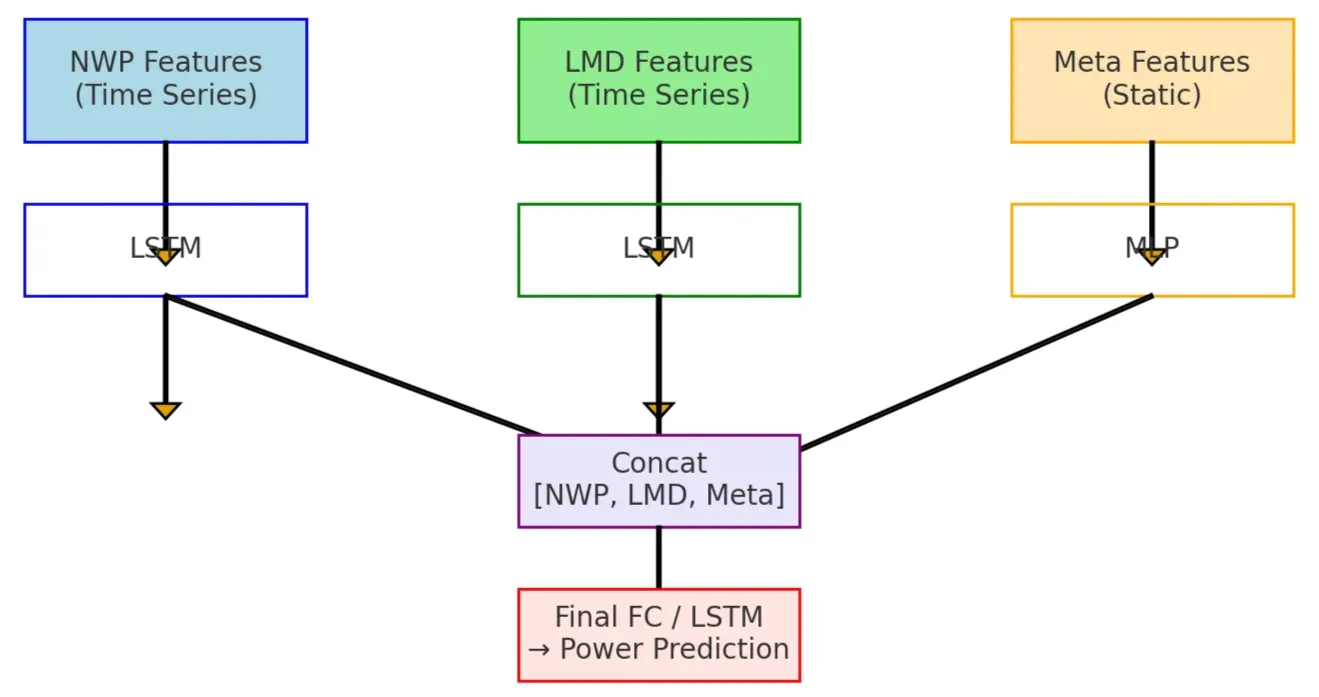

1. 텐서로 변환
2. Dataloader 생성
3. LSTM 생성
    - NWP - LSTM
    - LMD - LSTM
    - meta - MLP
    - 세 브랜치의 출력 벡터 concat
    - FC 레이어 혹은 LSTM으로 처리 -> power예측
4. 모델 학습 
    - 여러 발전소를 동시에 학습하여 공통 패턴과 발전소 특성을 함께 반영
    - 학습 시 station 데이터와 metadata 병합
5. 모델 성능 계산
    - 각 station 별 power 예측
    - MAE, RMSE, MAPE
6. validation
7. 모델 예측
    - test 데이터 사용
    - 각 station 별 power 예측

1. 모델 초기화

In [47]:
# 공통 파라미터
input_size  = torch_train_x.shape[-1] # 22
output_size = torch_train_y.shape[-1] if torch_train_y.dim() == 2 else 1
num_stations = len(station_to_idx)
meta_dim = torch_train_meta.shape[1] if 'torch_train_meta' in globals() and torch_train_meta is not None else 0
station_emb_dim = 12
dropout = 0.1

In [48]:
# LSTM 파라미터
num_ls_layers = 1
hidden_size = 96

LSTM = PVPlantLSTM(
    input_size=input_size,
    hidden_size=hidden_size,
    output_size=output_size, # 1
    num_layers=num_ls_layers,
    bidirectional=False,
    num_stations=num_stations,
    station_emb_dim=station_emb_dim,
    meta_dim=meta_dim,
    dropout=dropout
).to(device)
LSTM

PVPlantLSTM(
  (lstm): LSTM(22, 96, batch_first=True)
  (st_emb): Embedding(10, 12)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [49]:
# Transformer 파라미터
d_model = 128
nhead = 8
dim_feedforward = 512
num_ts_layers = 3

Transformer = PVPlantTransformer(
    input_size=input_size, # LSTM의 input_size와 동일
    d_model=d_model, # hidden_size
    output_size=output_size, # 예측 스텝 수
    num_layers=num_ts_layers, # 인코더 레이어 수
    num_stations=num_stations, # station 개수
    station_emb_dim=station_emb_dim, # station 임베딩 차원
    meta_dim=meta_dim, # 메타 피처 차원
    dropout=0.2, # 드롭아웃 비율
    nhead=nhead, # 멀티헤드 어텐션 헤드 수
    dim_feedforward=dim_feedforward, # 피드포워드 네트워크 차원
    max_len=input_window, # 최대 시퀀스 길이
    pool="last" 
).to(device)
Transformer

PVPlantTransformer(
  (embedding): TimeSeriesEmbedding(
    (input_proj): Linear(in_features=22, out_features=128, bias=True)
    (pos_encoder): PositionalEncoding()
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (enc_norm): 

In [50]:
# (x, y, s, meta) 튜플로 묶어서 DataLoader에 전달
train_ds = SeqDataset(torch_train_x, torch_train_y, torch_train_s, torch_train_meta if meta_dim>0 else None)
valid_ds = SeqDataset(torch_valid_x, torch_valid_y, torch_valid_s, torch_valid_meta if meta_dim>0 else None)
test_ds  = SeqDataset(torch_test_x,  torch_test_y,  torch_test_s,  torch_test_meta  if meta_dim>0 else None)

# DataLoader로 배치 사이즈에 맞춰 분할
batch_size = 512
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

In [51]:
model_list = [
    ('LSTM', LSTM),
    ('Transformer', Transformer)
]

In [52]:
for model_name, model in model_list:
    # 손실함수, 옵티마이저 설정
    criterion = nn.HuberLoss(delta=1.0, reduction="mean")
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    num_epochs = 10 # epoch 수
    best_loss = float('inf')
    best_path = f'results/best_{model_name}_test.pth'

    for epoch in range(1, num_epochs + 1):
        # 1. 학습
        train_loss = train(train_loader, model, criterion, optimizer, device)

        # 2. 검증: 전체 평균 손실 + station별 평균 손실
        overall_loss, station_avg = evaluate(valid_loader, model, criterion, device)

        # 3. best model 저장 (전체 평균 손실 기준)
        if overall_loss < best_loss:
            best_loss = overall_loss
            torch.save(model.state_dict(), best_path)
            print(f"[{model_name}] ({epoch:03d}) Saved best | valid loss: {best_loss:.6f}")

            items = ", ".join([f"{k}: {v:.6f}" for k, v in sorted(station_avg.items(), key=lambda x: x[0])])
            print(f"[{model_name}] station_loss: {{{items}}}")

        # 4. 출력: train/valid (전체) 손실
        print(f"[{model_name}] ({epoch:03d}) train {train_loss:.6f} | valid {overall_loss:.6f}")


[LSTM] (001) Saved best | valid loss: 0.010678
[LSTM] station_loss: {0: 0.009726, 1: 0.010414, 2: 0.010709, 3: 0.009274, 4: 0.017957, 5: 0.015044, 6: 0.008220, 7: 0.009745, 8: 0.008813, 9: 0.008188}
[LSTM] (001) train 0.031458 | valid 0.010678
[LSTM] (002) train 0.009935 | valid 0.011900
[LSTM] (003) train 0.009355 | valid 0.015173
[LSTM] (004) Saved best | valid loss: 0.009792
[LSTM] station_loss: {0: 0.006944, 1: 0.009234, 2: 0.010981, 3: 0.009740, 4: 0.015080, 5: 0.015207, 6: 0.008401, 7: 0.008304, 8: 0.008580, 9: 0.009243}
[LSTM] (004) train 0.009180 | valid 0.009792
[LSTM] (005) train 0.008909 | valid 0.009985
[LSTM] (006) train 0.008815 | valid 0.011728
[LSTM] (007) train 0.008750 | valid 0.010778
[LSTM] (008) train 0.008707 | valid 0.011649
[LSTM] (009) Saved best | valid loss: 0.009158
[LSTM] station_loss: {0: 0.006553, 1: 0.009292, 2: 0.009666, 3: 0.007122, 4: 0.014177, 5: 0.017328, 6: 0.007599, 7: 0.008488, 8: 0.008141, 9: 0.007516}
[LSTM] (009) train 0.008692 | valid 0.00915

In [53]:
# valid의 평가 지표 계산
for model_name, model in model_list:
    best_path = f'results/best_{model_name}_test.pth'
    val_mae, val_rmse, val_mape, val_r2 = metrics(best_path, model, valid_loader, y_scaler, device)
    print(f"[Valid evaluation | {model_name}] Valid MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, MAPE: {val_mape:.4f}, R2: {val_r2:.4f}")

[Valid evaluation | LSTM] Valid MAE: 0.4397, RMSE: 1.1986, MAPE: 15.9169, R2: 0.9664
[Valid evaluation | Transformer] Valid MAE: 0.7739, RMSE: 1.7136, MAPE: 50.8613, R2: 0.9312


### Test 데이터 평가

In [54]:
# 추후

## 6. Deployment

- 발전소별 예측값 vs 실제값 시각화 

valid_df 실제 데이터 시각화

In [101]:
# valid의 평가 지표 계산
model_list = [
    ('LSTM', LSTM),
    ('Transformer', Transformer)
]
for model_name, model in model_list:
    best_path = f'results/best_{model_name}_test.pth'
    val_mae, val_rmse, val_mape, val_r2 = metrics(best_path, model, valid_loader, y_scaler, device)
    print(f"[Valid evaluation | {model_name}] Valid MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, MAPE: {val_mape:.4f}, R2: {val_r2:.4f}")

[Valid evaluation | LSTM] Valid MAE: 0.4236, RMSE: 1.1815, MAPE: 14.2767, R2: 0.9673
[Valid evaluation | Transformer] Valid MAE: 0.5517, RMSE: 1.3448, MAPE: 18.1072, R2: 0.9577


In [94]:
best_lstm_path = 'results/best_LSTM_test.pth'
best_transformer_path = 'results/best_Transformer_test.pth'

# best_lstm = PVPlantLSTM(
#     input_size=input_size,
#     hidden_size=hidden_size,
#     output_size=output_size, # 1
#     num_layers=num_ls_layers,
#     bidirectional=False,
#     num_stations=num_stations,
#     station_emb_dim=station_emb_dim,
#     meta_dim=meta_dim,
#     dropout=dropout
# ).to(device)

# best_transformer = PVPlantTransformer(
#     input_size=input_size, # LSTM의 input_size와 동일
#     d_model=d_model, # hidden_size
#     output_size=output_size, # 예측 스텝 수
#     num_layers=num_ts_layers, # 인코더 레이어 수
#     num_stations=num_stations, # station 개수
#     station_emb_dim=station_emb_dim, # station 임베딩 차원
#     meta_dim=meta_dim, # 메타 피처 차원
#     dropout=dropout, # 드롭아웃 비율
#     nhead=nhead, # 멀티헤드 어텐션 헤드 수
#     dim_feedforward=dim_feedforward, # 피드포워드 네트워크 차원
#     max_len=input_window, # 최대 시퀀스 길이
#     pool="last" 
# ).to(device)

best_lstm = LSTM
best_transformer = Transformer

# best model 불러오기
best_lstm.load_state_dict(torch.load(best_lstm_path, map_location=device))
best_transformer.load_state_dict(torch.load(best_transformer_path, map_location=device))

<All keys matched successfully>

output_window가 여러 개일 때 사용

In [95]:
# plot_station_with_predictions(
#     model=best_lstm,
#     valid_loader=valid_loader,
#     valid_df=valid_df,
#     device=device,
#     input_len=input_window,
#     output_len=output_window,
#     start_idx=0,
#     feature_idx=0,
#     y_scaler=y_scaler,
#     log_target=True,
#     max_plots=10
# )

In [96]:
# plot_station_with_predictions(
#     model=best_transformer,
#     valid_loader=valid_loader,
#     valid_df=valid_df,
#     device=device,
#     input_len=input_window,
#     output_len=output_window,
#     start_idx=0,
#     feature_idx=0,
#     y_scaler=y_scaler,
#     log_target=True,
#     max_plots=10
# )

Output_window가 1개 일 때, 여러 날짜를 시각화할 때 사용

In [ ]:
# import numpy as np
# import pandas as pd
# import torch
# import matplotlib.pyplot as plt

# def plot_station_2days_forecast(
#     model, valid_loader, valid_df, device,
#     input_len=10, output_len=1, start_idx=0,
#     y_scaler=None,
#     log_target=True,
#     station_id=None,
#     view_days=2,
#     max_plots=None,
#     permute_to_BFL=False,
#     save_path=None
# ):
#     """
#     [주요 수정]
#     - 예측 시점 타임스탬프 매핑 로직 수정
#     - input 윈도우의 시작 인덱스와 예측 타임스탬프를 명확히 분리
#     """
    
#     # ========== 역변환 함수 ==========
#     def _inv_standard_log1p(arr_1d: np.ndarray) -> np.ndarray:
#         a = arr_1d.reshape(-1, 1)
#         if y_scaler is not None:
#             a = y_scaler.inverse_transform(a)
#         a = a.ravel()
#         if log_target:
#             a = np.expm1(a)
#             a = np.maximum(a, 0)
#         return a

#     # ========== 데이터 준비 ==========
#     df_all = valid_df.copy()
#     if "date_time" in df_all.columns:
#         df_all["date_time"] = pd.to_datetime(df_all["date_time"])
    
#     df_all = df_all.reset_index(drop=True)
#     df_all['global_idx'] = df_all.index

#     # 스테이션 목록 추출
#     if "Station_ID" in df_all.columns:
#         all_stations = df_all["Station_ID"].astype(str).unique().tolist()
#     else:
#         all_stations = [None]

#     # station_id 정규화
#     if station_id is None:
#         station_list = all_stations[:1]
#     elif isinstance(station_id, (list, tuple, pd.Series, np.ndarray)):
#         station_list = pd.Series(station_id, dtype="object").astype(str).unique().tolist()
#     else:
#         station_list = [str(station_id)]

#     if max_plots is not None:
#         station_list = station_list[:int(max_plots)]

#     # ========== 배치 언패킹 함수 ==========
#     def _unpack_batch(batch):
#         xb = batch[0]
#         s_idx = None
#         meta = None
#         if len(batch) >= 2 and isinstance(batch[1], torch.Tensor):
#             if len(batch) == 4:
#                 s_idx, meta = batch[1], batch[2]
#             elif len(batch) == 3:
#                 s_idx = batch[1]
#         return xb, s_idx, meta

#     # ========== 스테이션별 예측 및 시각화 ==========
#     for sid in station_list:
#         print(f"\n{'='*60}")
#         print(f"Processing Station: {sid}")
#         print(f"{'='*60}")
        
#         # 스테이션 데이터 필터링
#         if sid is None or "Station_ID" not in df_all.columns:
#             df = df_all.copy()
#         else:
#             df = df_all[df_all["Station_ID"].astype(str) == sid].copy()

#         df = df.sort_values("date_time").reset_index(drop=True)
        
#         if start_idx + input_len >= len(df):
#             print(f"[경고] Station {sid}: 데이터 부족")
#             continue

#         # ========== 시간 구간 설정 ==========
#         start_time = df.loc[start_idx, "date_time"]
#         input_start = start_time
#         input_end = df.loc[start_idx + input_len - 1, "date_time"]
#         view_end = start_time + pd.Timedelta(days=view_days)

#         input_mask = (df["date_time"] >= input_start) & (df["date_time"] <= input_end)
#         input_part = df.loc[input_mask, ["date_time", "power"]].copy()
        
#         output_mask = (df["date_time"] > input_end) & (df["date_time"] <= view_end)
#         output_part = df.loc[output_mask, ["date_time", "power"]].copy()

#         # ========== 예측 인덱스 계산 (수정됨!) ==========
#         """
#         핵심 개념:
#         - input_window_start: 입력 윈도우의 시작 로컬 인덱스 (모델에 넣을 샘플)
#         - pred_timestamp_idx: 예측값이 대응되는 실제 타임스탬프의 로컬 인덱스
        
#         예시 (input_len=10, output_len=1):
#         - 윈도우 [0~9] → 예측 시점 10
#         - 윈도우 [1~10] → 예측 시점 11
#         """
#         prediction_info = []  # [(global_idx, input_start_local, pred_timestamp_local), ...]
        
#         current_local_idx = start_idx
        
#         while True:
#             # 입력 윈도우: [current_local_idx : current_local_idx + input_len]
#             # 예측 시점: current_local_idx + input_len
#             pred_timestamp_idx = current_local_idx + input_len
            
#             if pred_timestamp_idx >= len(df):
#                 break
            
#             pred_time = df.loc[pred_timestamp_idx, "date_time"]
#             if pred_time > view_end:
#                 break
            
#             # 글로벌 인덱스는 입력 윈도우의 시작점 기준
#             global_idx = df.loc[current_local_idx, 'global_idx']
#             prediction_info.append((global_idx, current_local_idx, pred_timestamp_idx))
            
#             current_local_idx += 1
            
#             if len(prediction_info) > 10000:
#                 print(f"[경고] Station {sid}: 예측 인덱스 과다")
#                 break

#         if not prediction_info:
#             print(f"[경고] Station {sid}: 예측 가능한 인덱스 없음")
#             continue

#         print(f"예측 샘플 수: {len(prediction_info)}")
#         print(f"글로벌 인덱스 범위: {prediction_info[0][0]} ~ {prediction_info[-1][0]}")
#         print(f"예측 시점 범위: {df.loc[prediction_info[0][2], 'date_time']} ~ {df.loc[prediction_info[-1][2], 'date_time']}")

#         # ========== 모델 예측 수행 ==========
#         model.eval()
#         pred_map = {}
#         batch_offset = 0
        
#         with torch.no_grad():
#             for batch_idx, batch in enumerate(valid_loader):
#                 xb, s_idx, meta = _unpack_batch(batch)
#                 batch_size = xb.size(0)
#                 batch_start = batch_offset
#                 batch_end = batch_offset + batch_size

#                 # 현재 배치에 포함된 예측 샘플 찾기
#                 samples_in_batch = [(g, inp_start, pred_ts) 
#                                    for g, inp_start, pred_ts in prediction_info 
#                                    if batch_start <= g < batch_end]
                
#                 if samples_in_batch:
#                     xb_dev = xb.to(device, non_blocking=True)
                    
#                     if permute_to_BFL and xb_dev.dim() == 3:
#                         xb_dev = xb_dev.permute(0, 2, 1)

#                     kwargs = {}
#                     if s_idx is not None:
#                         kwargs["station_idx"] = s_idx.to(device, non_blocking=True)
#                     if meta is not None:
#                         meta_dev = meta.to(device, non_blocking=True)
#                         if meta_dev.dim() == 3:
#                             meta_dev = meta_dev.mean(dim=1)
#                         kwargs["meta"] = meta_dev

#                     # 모델 forward
#                     try:
#                         yhat = model(xb_dev, **kwargs)
#                     except TypeError:
#                         try:
#                             yhat = model(xb_dev, 
#                                        kwargs.get("station_idx", None), 
#                                        kwargs.get("meta", None))
#                         except TypeError:
#                             yhat = model(xb_dev)

#                     yhat_np = yhat.detach().cpu().numpy()  # [B, output_len]
                    
#                     for g_idx, inp_start, pred_ts_idx in samples_in_batch:
#                         batch_offset_idx = g_idx - batch_start
#                         pred_seq = _inv_standard_log1p(yhat_np[batch_offset_idx].reshape(-1))
                        
#                         # ✅ 핵심 수정: pred_ts_idx 사용 (예측 시점의 실제 타임스탬프)
#                         pred_timestamp = df.loc[pred_ts_idx, "date_time"]
                        
#                         # output_len만큼 매핑 (일반적으로 1개)
#                         for step in range(min(output_len, len(pred_seq))):
#                             if pred_ts_idx + step < len(df):
#                                 ts = df.loc[pred_ts_idx + step, "date_time"]
#                                 ts = pd.Timestamp(ts)
#                                 if ts <= view_end:
#                                     pred_map[ts] = float(pred_seq[step])
                    
#                     # 첫 배치 디버깅
#                     if batch_idx == 0 and samples_in_batch:
#                         g0, inp0, pred0 = samples_in_batch[0]
#                         offset0 = g0 - batch_start
#                         print(f"\n[디버깅 - 첫 예측 샘플]")
#                         print(f"  입력 윈도우 로컬 인덱스: {inp0} ~ {inp0 + input_len - 1}")
#                         print(f"  예측 타임스탬프 로컬 인덱스: {pred0}")
#                         print(f"  예측 시점: {df.loc[pred0, 'date_time']}")
#                         print(f"  배치 내 오프셋: {offset0}")
#                         if s_idx is not None:
#                             print(f"  station_idx: {s_idx[offset0].item()}")
#                         print(f"  모델 출력 (표준화됨): {yhat_np[offset0][:3]}")
#                         print(f"  역변환 후 (kW): {_inv_standard_log1p(yhat_np[offset0].reshape(-1))[:3]}")

#                 batch_offset += batch_size
                
#                 if batch_offset > max([g for g, _, _ in prediction_info]):
#                     break

#         if not pred_map:
#             print(f"[경고] Station {sid}: 예측 결과 생성 실패")
#             continue

#         print(f"생성된 예측 포인트 수: {len(pred_map)}")

#         # ========== 시각화 ==========
#         pred_series = pd.Series(pred_map).sort_index()
        
#         plt.figure(figsize=(14, 6))
        
#         plt.plot(input_part["date_time"], input_part["power"], 
#                 color='#1f77b4', label="Input (Actual)", linewidth=2.5, marker='o', markersize=5)
        
#         plt.plot(output_part["date_time"], output_part["power"], 
#                 color='#ff7f0e', label="Output (Actual)", linewidth=2.5, marker='s', markersize=4)
        
#         plt.plot(pred_series.index, pred_series.values, 
#                 color='#2ca02c', linestyle="--", label="Predicted", 
#                 linewidth=2.5, marker="^", markersize=5, alpha=0.85)
    
        
#         title = f"PVPlant Power Forecast | In_window={input_len}, Out_window={output_len}"
#         if sid is not None:
#             title += f" | Station {sid}"
        
#         plt.title(title, fontsize=14, fontweight='bold')
#         plt.xlabel("Time", fontsize=12)
#         plt.ylabel("Power (kW)", fontsize=12)
#         plt.xticks(rotation=45)
#         plt.grid(True, alpha=0.3, linestyle='--')
#         plt.legend(loc="best", fontsize=11)
#         plt.xlim([input_start, view_end])
#         plt.tight_layout()

#         if save_path is not None:
#             if len(station_list) == 1:
#                 out_path = save_path
#             else:
#                 base, ext = (save_path.rsplit(".", 1) + ["png"])[:2]
#                 out_path = f"{base}_{sid}.{ext}"
#             plt.savefig(out_path, dpi=300, bbox_inches="tight")
#             print(f"[저장] {out_path}")
        
#         plt.show()

In [124]:
from utils.setup import _to_device

In [128]:
def plot_station_2days_forecast(
    model, valid_loader, valid_df, device,
    input_len=10, output_len=1, start_idx=0,
    y_scaler=None,
    log_target=True,
    station_id=None,
    view_days=2,
    max_plots=None,
    permute_to_BFL=False,
    save_path=None
):
    """
    [주요 수정]
    - 예측 시점 타임스탬프 매핑 로직 수정
    - input 윈도우의 시작 인덱스와 예측 타임스탬프를 명확히 분리
    """
    
    # ========== 역변환 함수 ==========
    def _inv_standard_log1p(arr_1d: np.ndarray) -> np.ndarray:
        a = arr_1d.reshape(-1, 1)
        if y_scaler is not None:
            a = y_scaler.inverse_transform(a)
        a = a.ravel()
        if log_target:
            a = np.expm1(a)
            a = np.maximum(a, 0)
        return a

    # ========== 데이터 준비 ==========
    df_all = valid_df.copy()
    if "date_time" in df_all.columns:
        df_all["date_time"] = pd.to_datetime(df_all["date_time"])
    
    df_all = df_all.reset_index(drop=True)
    df_all['global_idx'] = df_all.index

    # 스테이션 목록 추출
    if "Station_ID" in df_all.columns:
        all_stations = df_all["Station_ID"].astype(str).unique().tolist()
    else:
        all_stations = [None]

    # station_id 정규화
    if station_id is None:
        station_list = all_stations[:1]
    elif isinstance(station_id, (list, tuple, pd.Series, np.ndarray)):
        station_list = pd.Series(station_id, dtype="object").astype(str).unique().tolist()
    else:
        station_list = [str(station_id)]

    if max_plots is not None:
        station_list = station_list[:int(max_plots)]

    # ========== 배치 언패킹 함수 ==========
    def _unpack_batch(batch):
        xb = batch[0]
        s_idx = None
        meta = None
        if len(batch) >= 2 and isinstance(batch[1], torch.Tensor):
            if len(batch) == 4:
                s_idx, meta = batch[1], batch[2]
            elif len(batch) == 3:
                s_idx = batch[1]
        return xb, s_idx, meta

    # ========== 스테이션별 예측 및 시각화 ==========
    for sid in station_list:
        print(f"\n{'='*60}")
        print(f"Processing Station: {sid}")
        print(f"{'='*60}")
        
        # 스테이션 데이터 필터링
        if sid is None or "Station_ID" not in df_all.columns:
            df = df_all.copy()
        else:
            df = df_all[df_all["Station_ID"].astype(str) == sid].copy()

        df = df.sort_values("date_time").reset_index(drop=True)
        
        if start_idx + input_len >= len(df):
            print(f"[경고] Station {sid}: 데이터 부족")
            continue

        # ========== 시간 구간 설정 ==========
        start_time = df.loc[start_idx, "date_time"]
        input_start = start_time
        input_end = df.loc[start_idx + input_len - 1, "date_time"]
        view_end = start_time + pd.Timedelta(days=view_days)

        input_mask = (df["date_time"] >= input_start) & (df["date_time"] <= input_end)
        input_part = df.loc[input_mask, ["date_time", "power"]].copy()
        
        output_mask = (df["date_time"] > input_end) & (df["date_time"] <= view_end)
        output_part = df.loc[output_mask, ["date_time", "power"]].copy()

        # ========== 예측 인덱스 계산 (수정됨!) ==========
        """
        핵심 개념:
        - input_window_start: 입력 윈도우의 시작 로컬 인덱스 (모델에 넣을 샘플)
        - pred_timestamp_idx: 예측값이 대응되는 실제 타임스탬프의 로컬 인덱스
        
        예시 (input_len=10, output_len=1):
        - 윈도우 [0~9] → 예측 시점 10
        - 윈도우 [1~10] → 예측 시점 11
        """
        prediction_info = []  # [(global_idx, input_start_local, pred_timestamp_local), ...]
        
        current_local_idx = start_idx
        
        while True:
            # 입력 윈도우: [current_local_idx : current_local_idx + input_len]
            # 예측 시점: current_local_idx + input_len
            pred_timestamp_idx = current_local_idx + input_len
            
            if pred_timestamp_idx >= len(df):
                break
            
            pred_time = df.loc[pred_timestamp_idx, "date_time"]
            if pred_time > view_end:
                break
            
            # 글로벌 인덱스는 입력 윈도우의 시작점 기준
            global_idx = df.loc[current_local_idx, 'global_idx']
            prediction_info.append((global_idx, current_local_idx, pred_timestamp_idx))
            
            current_local_idx += 1
            
            if len(prediction_info) > 10000:
                print(f"[경고] Station {sid}: 예측 인덱스 과다")
                break

        if not prediction_info:
            print(f"[경고] Station {sid}: 예측 가능한 인덱스 없음")
            continue

        print(f"예측 샘플 수: {len(prediction_info)}")
        print(f"글로벌 인덱스 범위: {prediction_info[0][0]} ~ {prediction_info[-1][0]}")
        print(f"예측 시점 범위: {df.loc[prediction_info[0][2], 'date_time']} ~ {df.loc[prediction_info[-1][2], 'date_time']}")

        # ========== 모델 예측 수행 ==========
        model.eval()
        pred_map = {}
        batch_offset = 0
        
        with torch.no_grad():
            for batch_idx, batch in enumerate(valid_loader):
                xb, s_idx, meta = _unpack_batch(batch)
                batch_size = xb.size(0)
                batch_start = batch_offset
                batch_end = batch_offset + batch_size

                # 현재 배치에 포함된 예측 샘플 찾기
                samples_in_batch = [(g, inp_start, pred_ts) 
                                   for g, inp_start, pred_ts in prediction_info 
                                   if batch_start <= g < batch_end]
                
                if samples_in_batch:
                    xb_dev = xb.to(device, non_blocking=True)
                    
                    if permute_to_BFL and xb_dev.dim() == 3:
                        xb_dev = xb_dev.permute(0, 2, 1)

                    kwargs = {}
                    if s_idx is not None:
                        kwargs["station_idx"] = s_idx.to(device, non_blocking=True)
                    if meta is not None:
                        meta_dev = meta.to(device, non_blocking=True)
                        if meta_dev.dim() == 3:
                            meta_dev = meta_dev.mean(dim=1)
                        kwargs["meta"] = meta_dev

                    # 모델 forward
                    try:
                        yhat = model(xb_dev, **kwargs)
                    except TypeError:
                        try:
                            yhat = model(xb_dev, 
                                       kwargs.get("station_idx", None), 
                                       kwargs.get("meta", None))
                        except TypeError:
                            yhat = model(xb_dev)

                    yhat_np = yhat.detach().cpu().numpy()  # [B, output_len]
                    
                    for g_idx, inp_start, pred_ts_idx in samples_in_batch:
                        batch_offset_idx = g_idx - batch_start
                        pred_seq = _inv_standard_log1p(yhat_np[batch_offset_idx].reshape(-1))
                        
                        # ✅ 핵심 수정: pred_ts_idx 사용 (예측 시점의 실제 타임스탬프)
                        pred_timestamp = df.loc[pred_ts_idx, "date_time"]
                        
                        # output_len만큼 매핑 (일반적으로 1개)
                        for step in range(min(output_len, len(pred_seq))):
                            if pred_ts_idx + step < len(df):
                                ts = df.loc[pred_ts_idx + step, "date_time"]
                                ts = pd.Timestamp(ts)
                                if ts <= view_end:
                                    pred_map[ts] = float(pred_seq[step])
                    
                    # 첫 배치 디버깅
                    if batch_idx == 0 and samples_in_batch:
                        g0, inp0, pred0 = samples_in_batch[0]
                        offset0 = g0 - batch_start
                        print(f"\n[디버깅 - 첫 예측 샘플]")
                        print(f"  입력 윈도우 로컬 인덱스: {inp0} ~ {inp0 + input_len - 1}")
                        print(f"  예측 타임스탬프 로컬 인덱스: {pred0}")
                        print(f"  예측 시점: {df.loc[pred0, 'date_time']}")
                        print(f"  배치 내 오프셋: {offset0}")
                        if s_idx is not None:
                            print(f"  station_idx: {s_idx[offset0].item()}")
                        print(f"  모델 출력 (표준화됨): {yhat_np[offset0][:3]}")
                        print(f"  역변환 후 (kW): {_inv_standard_log1p(yhat_np[offset0].reshape(-1))[:3]}")

                batch_offset += batch_size
                
                if batch_offset > max([g for g, _, _ in prediction_info]):
                    break

        if not pred_map:
            print(f"[경고] Station {sid}: 예측 결과 생성 실패")
            continue

        print(f"생성된 예측 포인트 수: {len(pred_map)}")

        # ========== 시각화 ==========
        pred_series = pd.Series(pred_map).sort_index()
        
        plt.figure(figsize=(14, 6))
        
        plt.plot(input_part["date_time"], input_part["power"], 
                color='#1f77b4', label="Input (Actual)", linewidth=2.5, marker='o', markersize=5)
        
        plt.plot(output_part["date_time"], output_part["power"], 
                color='#ff7f0e', label="Output (Actual)", linewidth=2.5, marker='s', markersize=4)
        
        plt.plot(pred_series.index, pred_series.values, 
                color='#2ca02c', linestyle="--", label="Predicted", 
                linewidth=2.5, marker="^", markersize=5, alpha=0.85)
    
        
        title = f"PVPlant Power Forecast | In_window={input_len}, Out_window={output_len}"
        if sid is not None:
            title += f" | Station {sid}"
        
        plt.title(title, fontsize=14, fontweight='bold')
        plt.xlabel("Time", fontsize=12)
        plt.ylabel("Power (kW)", fontsize=12)
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, linestyle='--')
        plt.legend(loc="best", fontsize=11)
        plt.xlim([input_start, view_end])
        plt.tight_layout()

        if save_path is not None:
            if len(station_list) == 1:
                out_path = save_path
            else:
                base, ext = (save_path.rsplit(".", 1) + ["png"])[:2]
                out_path = f"{base}_{sid}.{ext}"
            plt.savefig(out_path, dpi=300, bbox_inches="tight")
            print(f"[저장] {out_path}")
        
        plt.show()

In [129]:
import math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from utils.setup import _to_device

def plot_single_station_predictions_2days(
    model, valid_loader, valid_df, device,
    input_len=96, output_len=4, start_idx=0,
    y_scaler=None,      # 마지막 적용: StandardScaler(타깃)
    logged: bool = False, # log1p 학습이면 True
    station_id=None,      # 단일 스테이션이면 None 가능
    view_days: int = 2,   # 이틀짜리 뷰
    save_path=None
):
    '''
    Function: plot_single_station_predictions_2days
    입력: 
      - cnn, lstm: 분리된 CNN 인코더와 LSTM 디코더(또는 후단) 모델
      - valid_loader: shuffle=False인 검증용 DataLoader ([B, L, F] or [B, F, L])
      - valid_df: 검증 구간의 원본 시계열 DataFrame (date_time, power, Station_ID 포함 가정)
      - device: torch.device
      - input_len: 각 샘플 입력 길이(L)
      - output_len: 각 샘플 예측 길이(H)
      - start_idx: 시작 샘플 인덱스(로더 기준)
      - std_scaler, mm_scaler, target_idx, logged: 타깃 역변환 체인(Standard→MinMax→expm1)
      - station_id: 여러 스테이션이 섞여 있으면 특정 ID만 필터
      - view_days: 시각화하고 싶은 일수(기본 2일)
      - save_path: 저장 경로
    출력:
      - 없음(플롯 표시 및 필요시 저장)
    동작:
      - start_idx 시점부터 view_days 동안의 시간 구간을 정의
      - valid_loader의 연속 샘플 예측을 이어 붙여 2일 구간을 채움(rolling forecast 시각화)
    '''

    # ---------- 역변환 유틸(1D) : Standard → MinMax → (expm1) ----------
    # 역변환 (std_scaler -> mm_scaler -> (log))
    def _inv_standard_log1p(arr_1d: np.ndarray) -> np.ndarray:
        a = arr_1d.reshape(-1, 1)
        if y_scaler is not None:
            a = y_scaler.inverse_transform(a)
        a = a.ravel()
        if logged:
            a = np.expm1(a)
            a = np.maximum(a, 0)
        return a

    # ---------- 단일/다중 스테이션 DF 준비 ----------
    df = valid_df.copy()
    if "date_time" in df.columns:
        df["date_time"] = pd.to_datetime(df["date_time"])

    if "Station_ID" in df.columns:
        df["Station_ID"] = df["Station_ID"].astype(str)

        # station_id 가 None이면 첫 ID 사용
        if station_id is None:
            uids = sorted(df["Station_ID"].unique().tolist())
            if len(uids) > 1:
                print(f"[warn] 여러 Station_ID 감지. '{uids[0]}' 사용:", uids)
            station_id = uids[0]

        # station_id 가 리스트/튜플/셋/ndarray 면 isin으로 필터
        if isinstance(station_id, (list, tuple, set, np.ndarray)):
            keep_ids = [str(s) for s in station_id]
            df = df[df["Station_ID"].isin(keep_ids)].copy()
        else:
            # 단일 문자열이면 == 로 필터
            df = df[df["Station_ID"] == str(station_id)].copy()

    df = df.sort_values("date_time").reset_index(drop=True)


    # ---------- 시작/종료 시간 계산(2일 뷰) ----------
    if start_idx + input_len >= len(df):
        print(f"[warn] start_idx+input_len가 데이터 길이를 초과합니다.")
        return

    start_time = df.loc[start_idx, "date_time"]  # 시작 샘플의 시작 시각
    view_end_time = start_time + pd.Timedelta(days=view_days)

    # 입력 구간(파란색 실선)과 출력 구간(주황색 실선) 실제값 슬라이스를 시간으로 자르기
    # 입력: [start_time, start_time + input_len)
    input_start = start_time
    input_end   = df.loc[start_idx + input_len - 1, "date_time"]
    input_mask  = (df["date_time"] >= input_start) & (df["date_time"] <= input_end)
    input_part  = df.loc[input_mask, ["date_time", "power"]].copy()

    # 출력 실제값: (input_end, view_end_time] 범위
    out_mask    = (df["date_time"] > input_end) & (df["date_time"] <= view_end_time)
    output_part = df.loc[out_mask, ["date_time", "power"]].copy()

    # ---------- 예측을 2일 구간에 맞춰 이어 붙이기 ----------
    model.eval()

    # 필요한 샘플 인덱스들을 수집: 각 샘플 i가 예측하는 시간축은
    # df.iloc[i+input_len : i+input_len+output_len]의 date_time
    needed_indices = []
    i = start_idx
    while True:
        out_start_i = i + input_len                # 예측 시작 인덱스
        out_end_i = i + input_len + output_len   # 예측 끝(미포함)
        if out_start_i >= len(df):
            break
        # 이번 샘플의 예측이 시작되는 시간이 view_end_time을 이미 넘으면 종료
        t0 = df.loc[out_start_i, "date_time"]
        if t0 > view_end_time:
            break
        needed_indices.append(i)
        # 다음 샘플로 이동(한 스텝씩 굴리며 이어 붙임)
        i += 1
        # 안전장치: 과도 루프 방지
        if i - start_idx > 10_000:
            print("[warn] 너무 많은 인덱스가 요구됩니다. 중단합니다.")
            break

    if len(needed_indices) == 0:
        print("[warn] 예측에 사용할 샘플 인덱스가 없습니다.")
        return

    # 한 번의 로더 순회로 needed_indices에 해당하는 예측만 뽑아오기
    # seen: 지금까지 지나온 샘플 수(글로벌 오프셋)
    seen = 0
    # 예측 결과를 시간별로 누적(겹치면 최신 예측으로 덮어쓰기)
    pred_map = {}  # dict[datetime -> value]

    with torch.no_grad():
        for batch in valid_loader:
            # 1) 배치 언패킹 및 타입 검사
            if not isinstance(batch, (list, tuple)):
                raise ValueError("batch는 tuple/list여야 합니다.")
            if len(batch) < 4:
                raise ValueError("batch는 (xb, s_idx, meta, yb) 형태여야 합니다.")

            xb, s_idx, meta, yb = batch
            bs = xb.size(0)

            # 2) 이 배치가 커버하는 전역 인덱스 범위
            g0 = seen
            g1 = seen + bs  # 미포함

            # 3) 필요한 인덱스만 추출
            to_pick = [idx for idx in needed_indices if g0 <= idx < g1]
            if to_pick:
                # 4) 텐서들을 device로 이동
                xb_dev, s_idx_dev, meta_dev, _ = _to_device((batch), device)
                # 5) 모델 추론: forward(x, station_idx, meta)
                #    (학습 시와 동일한 시그니처 유지)
                try:
                    yhat = model(xb_dev, s_idx_dev, meta_dev)   # 기대 형태: [B, H] 또는 [B, H, 1]
                except TypeError:
                    # 예외적으로 모델이 x만 받도록 정의된 경우 방어적 처리
                    yhat = model(xb_dev)

                # 6) 출력 텐서 형태 정규화 및 numpy 변환
                if yhat.ndim == 3 and yhat.size(-1) == 1:       # [B, H, 1] -> [B, H]
                    yhat = yhat.squeeze(-1)
                elif yhat.ndim == 1:                            # [B] -> [B, 1] (희귀 케이스)
                    yhat = yhat.unsqueeze(-1)

                yhat_np = yhat.detach().cpu().numpy()           # [B, H]

                # 7) 필요한 샘플만 시간축에 매핑
                for idx in to_pick:
                    off = idx - g0                               # 배치 내부 오프셋
                    pred_seq = yhat_np[off].reshape(-1)          # [H,]
                    pred_seq = _inv_standard_log1p(pred_seq)       # 역변환(Standard -> expm1)

                    # 이 예측의 타임스탬프 범위 계산
                    s = idx + input_len
                    e = min(s + output_len, len(df))
                    times = df.loc[s:e-1, "date_time"].values

                    # view_end_time 넘는 부분 버리고, 같은 시간은 최신값으로 덮어쓰기
                    for t, v in zip(times, pred_seq[:len(times)]):
                        t_ts = pd.Timestamp(t)
                        if t_ts <= view_end_time:
                            pred_map[t_ts] = float(v)

            # 8) 다음 배치로 전진
            seen += bs

            # 9) 필요한 인덱스 모두 처리했으면 조기 종료(속도 향상)
            if seen > max(needed_indices):
                break


    # pred_map → 정렬된 시계열로 변환
    if len(pred_map) == 0:
        print("[warn] 예측 결과가 비어 있습니다.")
        return
    pred_series = pd.Series(pred_map).sort_index()
    pred_time   = pred_series.index
    y_pred_rec  = pred_series.values

    # ========== 시각화 ==========

    plt.figure(figsize=(14, 6))
    
    plt.plot(input_part["date_time"], input_part["power"], 
            color='#1f77b4', label="Input (Actual)", linewidth=2.5, marker='o', markersize=5)
    
    plt.plot(output_part["date_time"], output_part["power"], 
            color='#ff7f0e', label="Output (Actual)", linewidth=2.5, marker='s', markersize=4)
    
    plt.plot(pred_series.index, pred_series.values, 
            color='#2ca02c', linestyle="--", label="Predicted", 
            linewidth=2.5, marker="^", markersize=5, alpha=0.85)

    
    title = f"PVPlant Power Forecast | In_window={input_len}, Out_window={output_len}"
    if sid is not None:
        title += f" | Station {sid}"
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Time", fontsize=12)
    plt.ylabel("Power (kW)", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc="best", fontsize=11)
    plt.xlim([input_start, view_end_time])
    plt.tight_layout()

    if save_path is not None:
        if len(station_id) == 1:
            out_path = save_path
        else:
            base, ext = (save_path.rsplit(".", 1) + ["png"])[:2]
            out_path = f"{base}_{sid}.{ext}"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"[저장] {out_path}")
    
    plt.show()


Processing Station: station00
예측 샘플 수: 663
글로벌 인덱스 범위: 0 ~ 662
예측 시점 범위: 2019-03-18 02:30:00 ~ 2019-03-25 00:00:00

[디버깅 - 첫 예측 샘플]
  입력 윈도우 로컬 인덱스: 0 ~ 9
  예측 타임스탬프 로컬 인덱스: 10
  예측 시점: 2019-03-18 02:30:00
  배치 내 오프셋: 0
  station_idx: 0
  모델 출력 (표준화됨): [0.8185737]
  역변환 후 (kW): [3.3162022]
생성된 예측 포인트 수: 663
[저장] forecast_result_7_lstm_station00.png


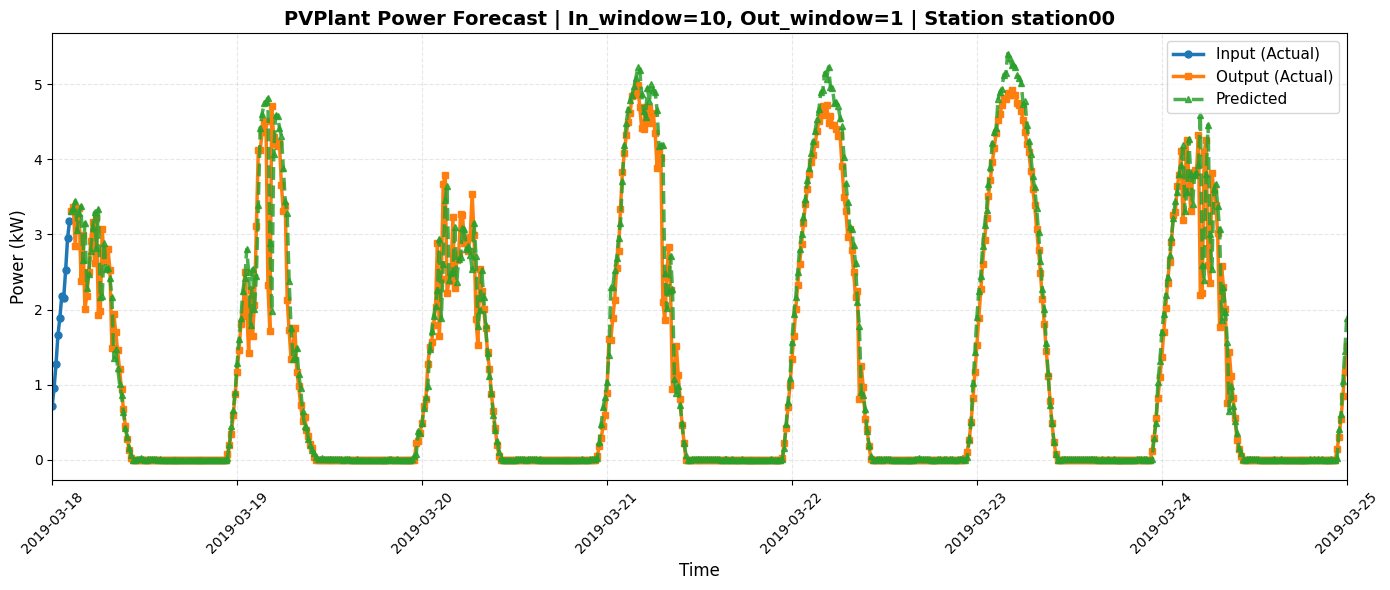


Processing Station: station01
예측 샘플 수: 663
글로벌 인덱스 범위: 3360 ~ 4022
예측 시점 범위: 2019-03-04 02:30:00 ~ 2019-03-11 00:00:00
생성된 예측 포인트 수: 663
[저장] forecast_result_7_lstm_station01.png


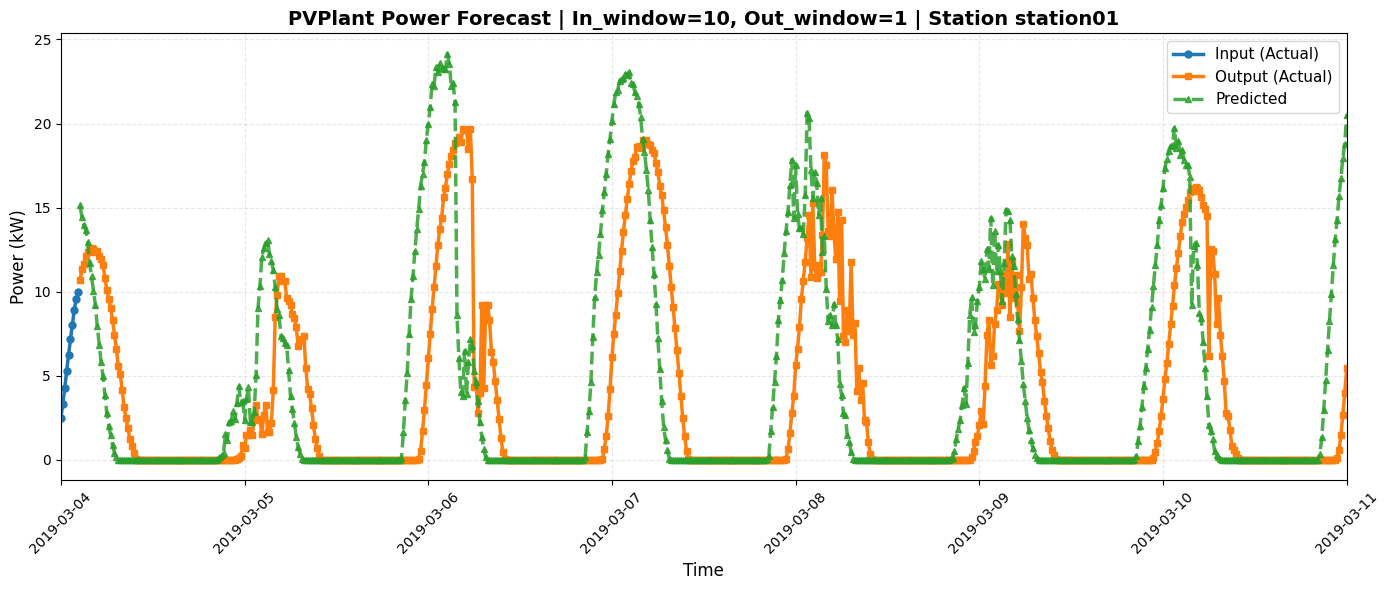


Processing Station: station02
예측 샘플 수: 663
글로벌 인덱스 범위: 7392 ~ 8054
예측 시점 범위: 2019-03-11 02:30:00 ~ 2019-03-18 00:00:00
생성된 예측 포인트 수: 663
[저장] forecast_result_7_lstm_station02.png


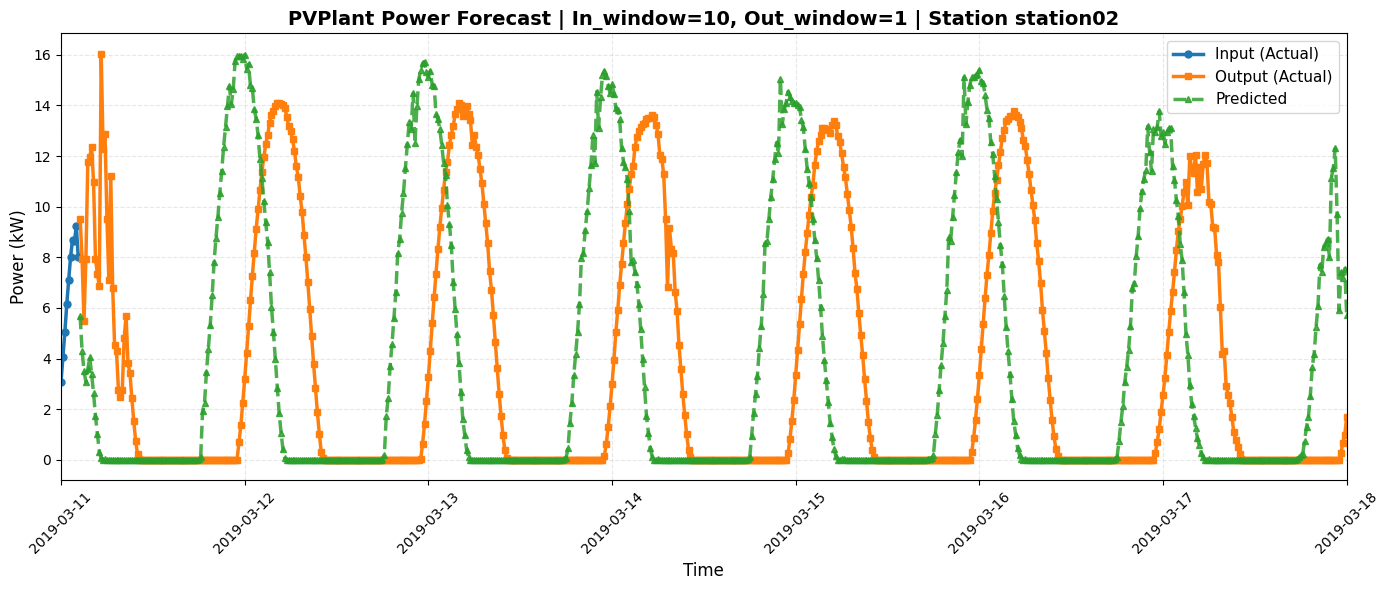


Processing Station: station03
예측 샘플 수: 663
글로벌 인덱스 범위: 10752 ~ 11414
예측 시점 범위: 2019-04-29 02:30:00 ~ 2019-05-06 00:00:00
생성된 예측 포인트 수: 663
[저장] forecast_result_7_lstm_station03.png


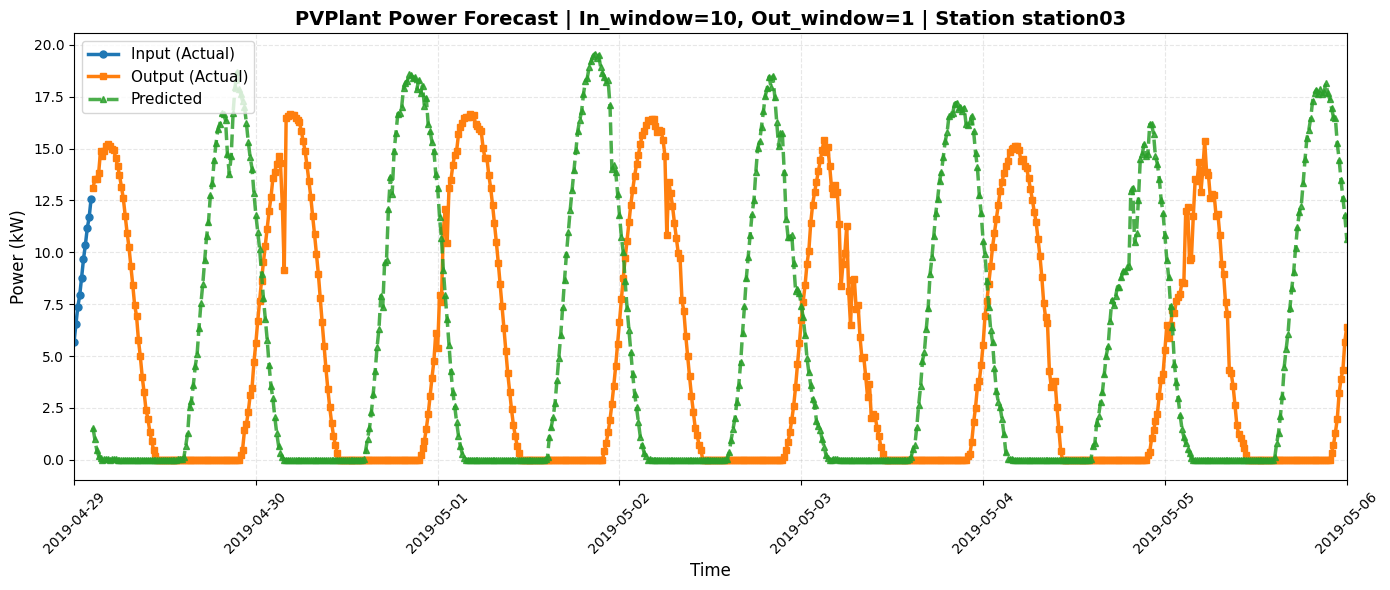


Processing Station: station04
예측 샘플 수: 663
글로벌 인덱스 범위: 12096 ~ 12758
예측 시점 범위: 2019-03-04 02:30:00 ~ 2019-03-11 00:00:00
생성된 예측 포인트 수: 663
[저장] forecast_result_7_lstm_station04.png


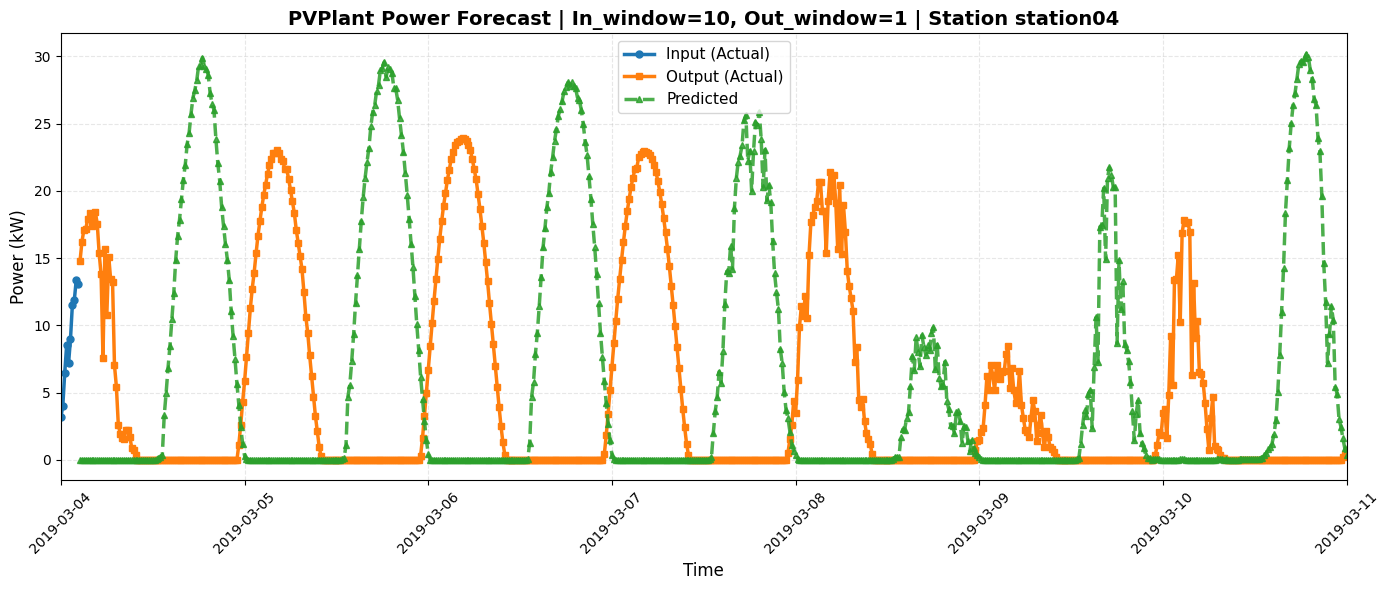


Processing Station: station05
예측 샘플 수: 662
글로벌 인덱스 범위: 16128 ~ 16789
예측 시점 범위: 2019-05-20 02:30:00 ~ 2019-05-26 23:45:00
생성된 예측 포인트 수: 662
[저장] forecast_result_7_lstm_station05.png


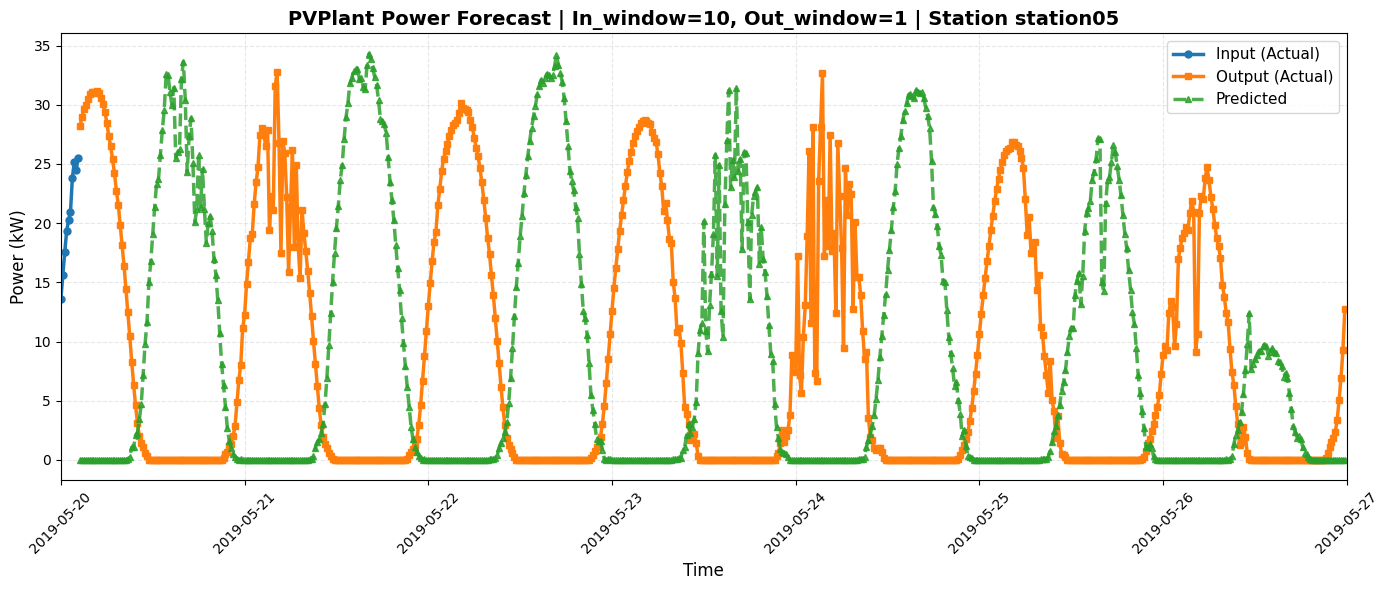


Processing Station: station06
예측 샘플 수: 663
글로벌 인덱스 범위: 16800 ~ 17462
예측 시점 범위: 2019-03-11 02:30:00 ~ 2019-03-18 00:00:00
생성된 예측 포인트 수: 663
[저장] forecast_result_7_lstm_station06.png


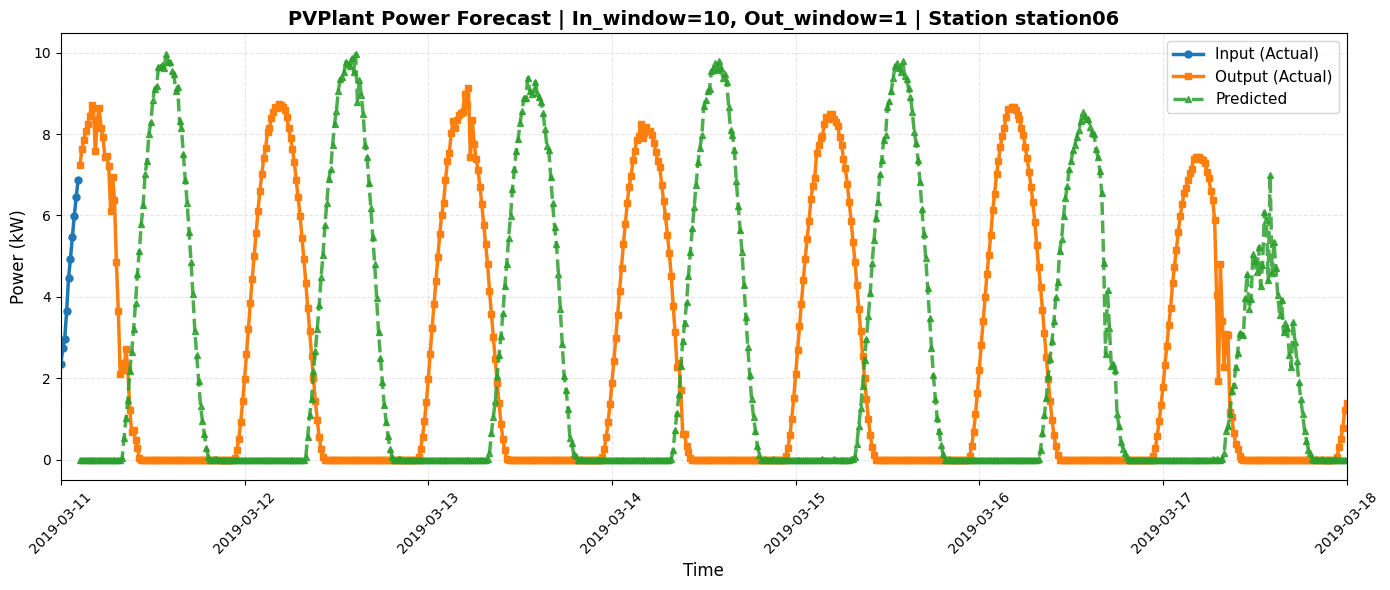


Processing Station: station07
예측 샘플 수: 663
글로벌 인덱스 범위: 20160 ~ 20822
예측 시점 범위: 2019-03-04 02:30:00 ~ 2019-03-11 00:00:00
생성된 예측 포인트 수: 663
[저장] forecast_result_7_lstm_station07.png


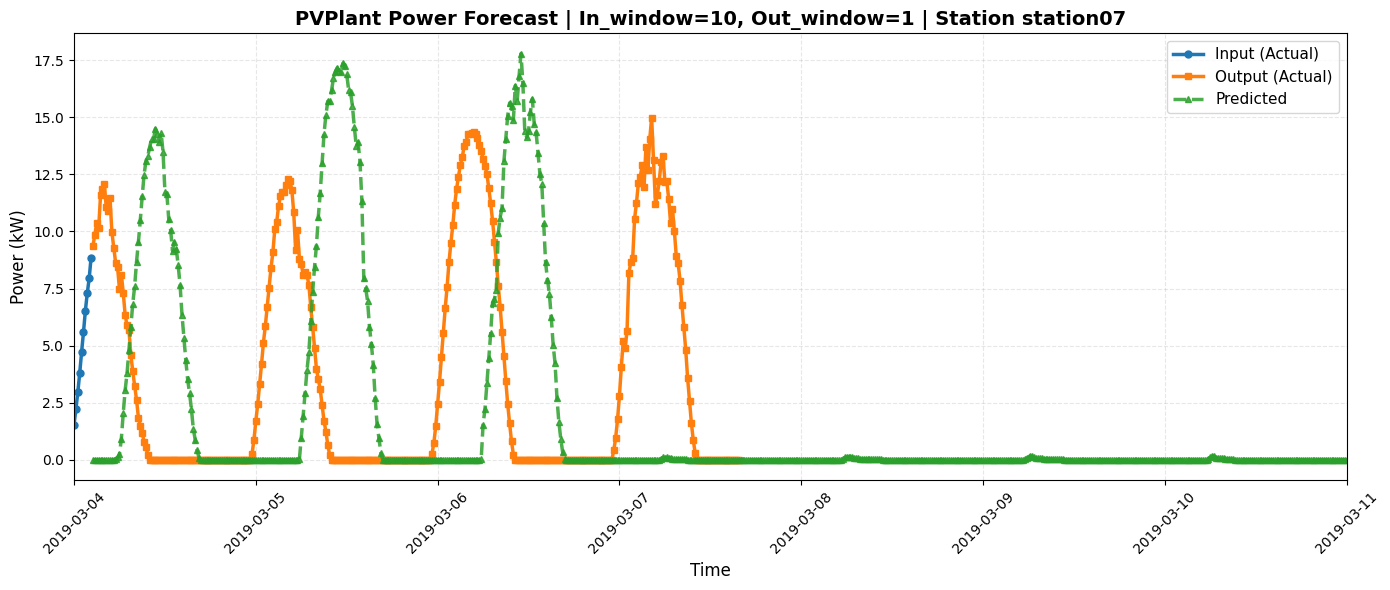


Processing Station: station08
예측 샘플 수: 663
글로벌 인덱스 범위: 24192 ~ 24854
예측 시점 범위: 2019-03-04 02:30:00 ~ 2019-03-11 00:00:00
생성된 예측 포인트 수: 663
[저장] forecast_result_7_lstm_station08.png


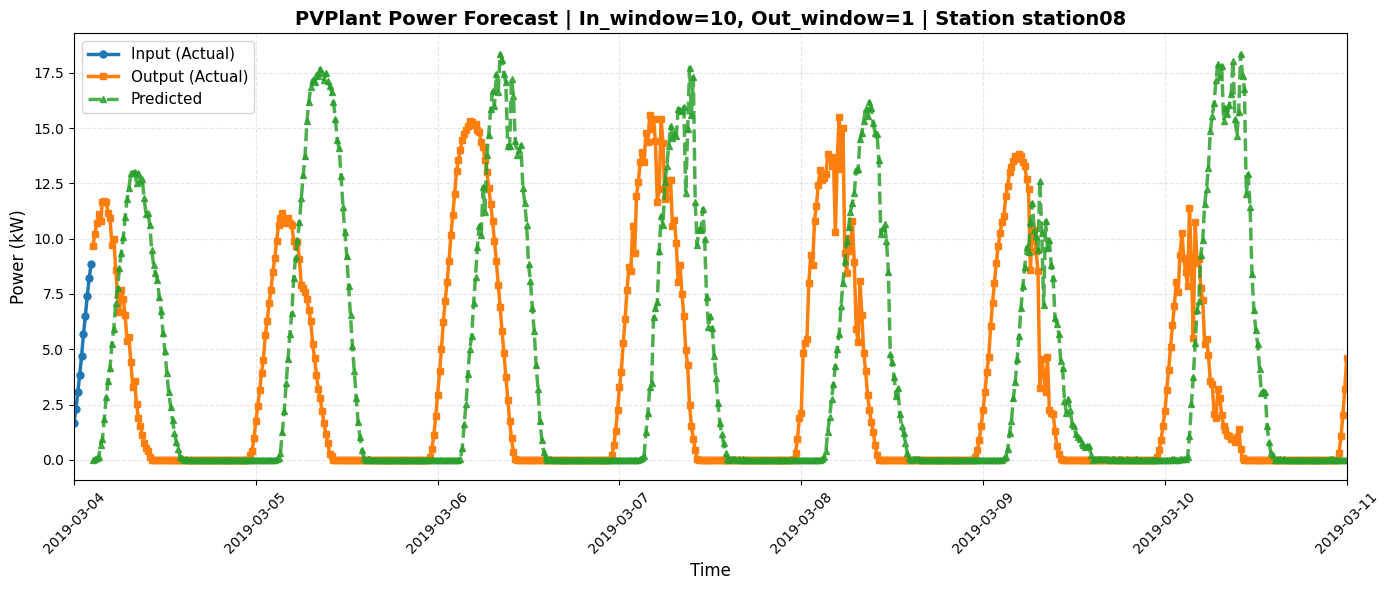


Processing Station: station09
예측 샘플 수: 663
글로벌 인덱스 범위: 28224 ~ 28886
예측 시점 범위: 2019-04-01 02:30:00 ~ 2019-04-08 00:00:00
생성된 예측 포인트 수: 663
[저장] forecast_result_7_lstm_station09.png


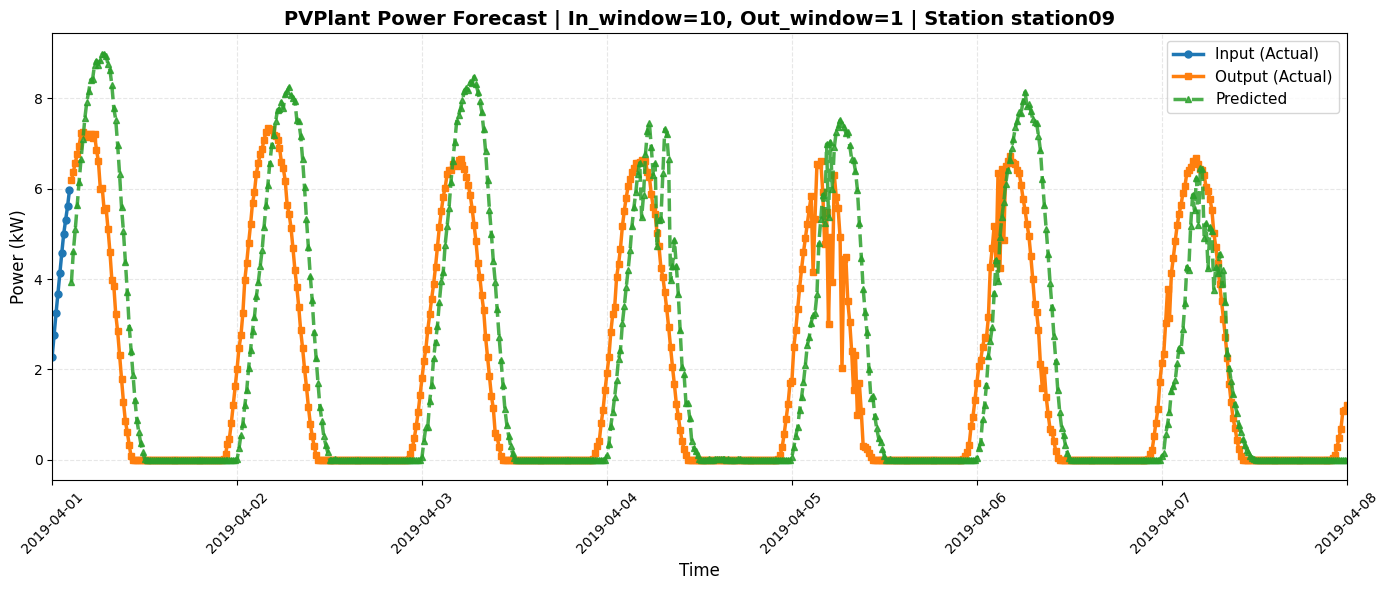

In [130]:
# 1) 모델 forward 차원 에러 먼저 수정(위 패치 참조)

# 2) 스테이션 리스트로 넘기기
station_list = stations["Station_ID"].astype(str).unique().tolist()

plot_station_2days_forecast(
    model=best_lstm,
    valid_loader=valid_loader,
    valid_df=valid_df,
    device=torch.device('cuda'),
    input_len=10,
    output_len=1,
    start_idx=0,
    y_scaler=y_scaler,
    log_target=True,
    station_id=station_list,
    view_days=7,
    save_path='forecast_result_7_lstm.png'
)

[저장] forecast_result_7_lstm_station00_station00.png


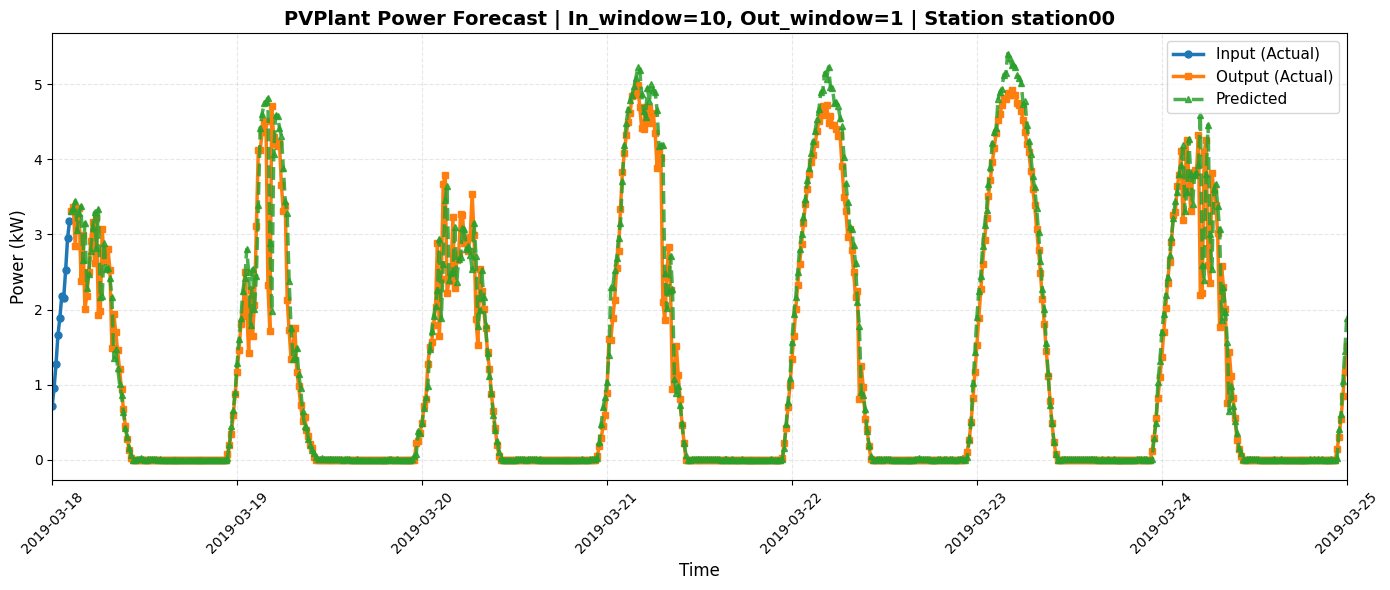

[저장] forecast_result_7_lstm_station01_station01.png


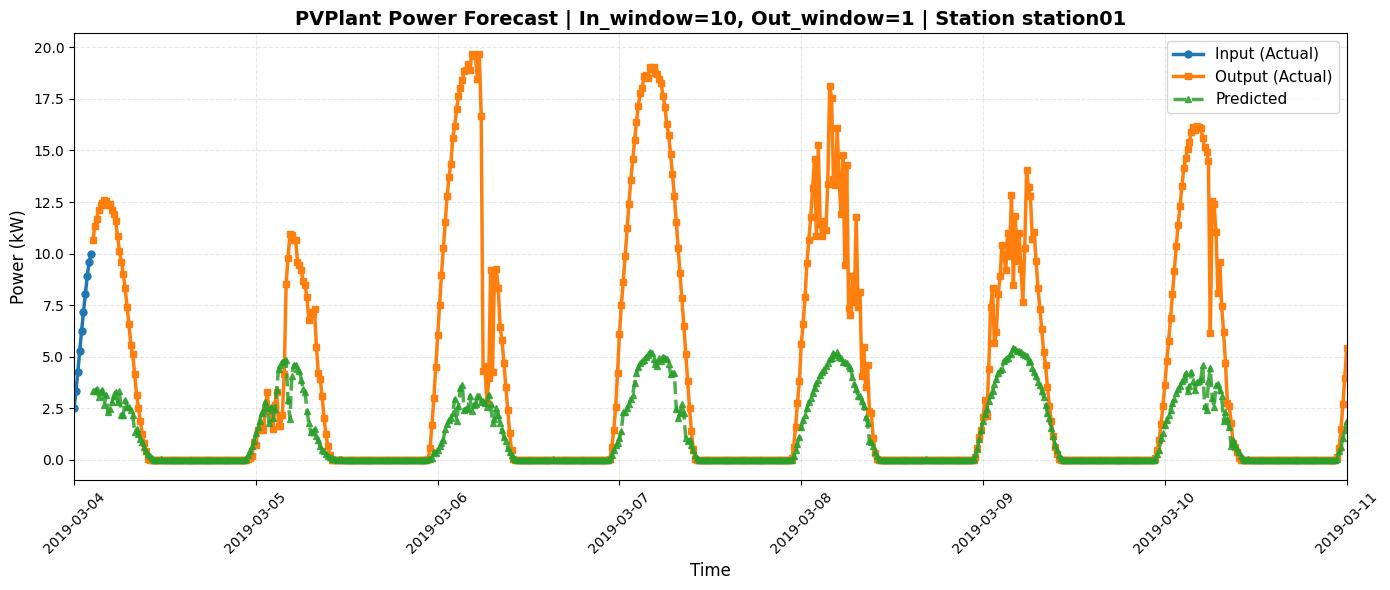

[저장] forecast_result_7_lstm_station02_station02.png


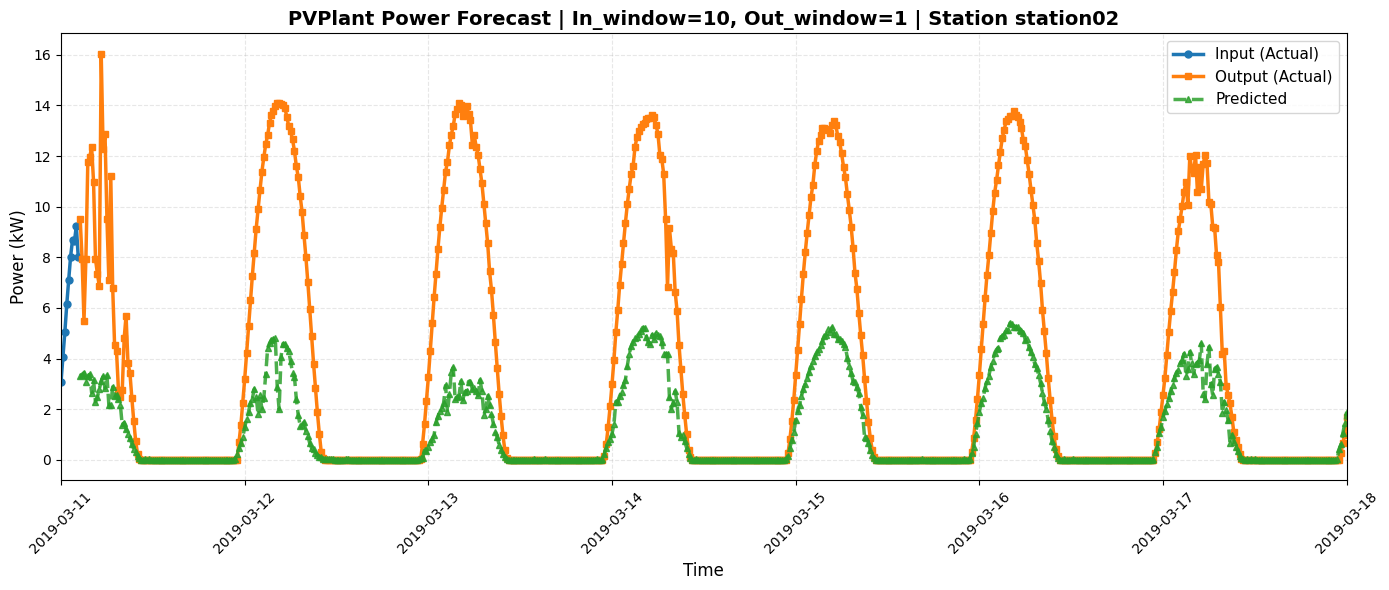

[저장] forecast_result_7_lstm_station03_station03.png


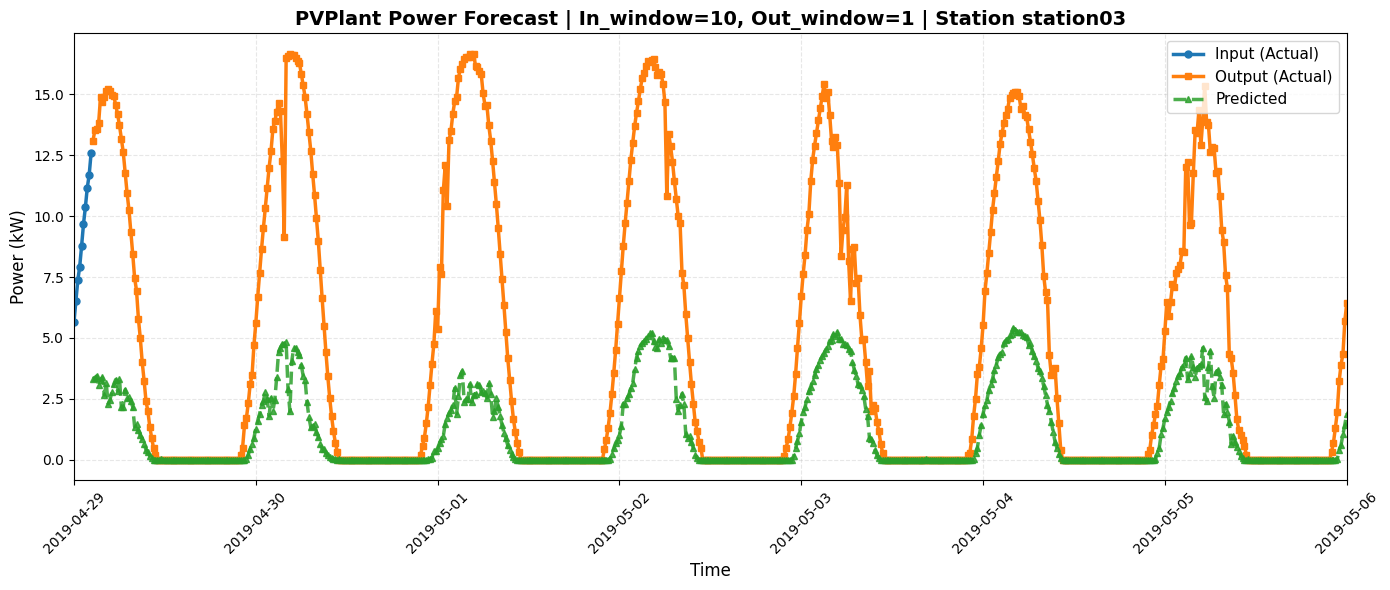

[저장] forecast_result_7_lstm_station04_station04.png


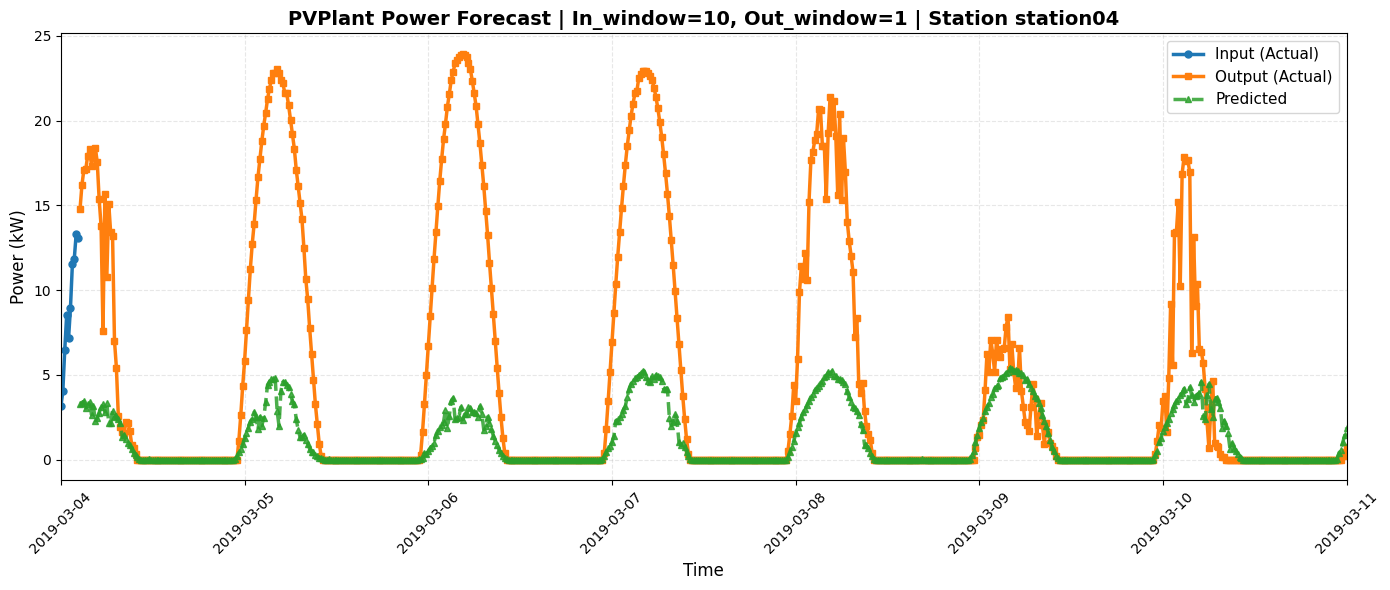

[저장] forecast_result_7_lstm_station05_station05.png


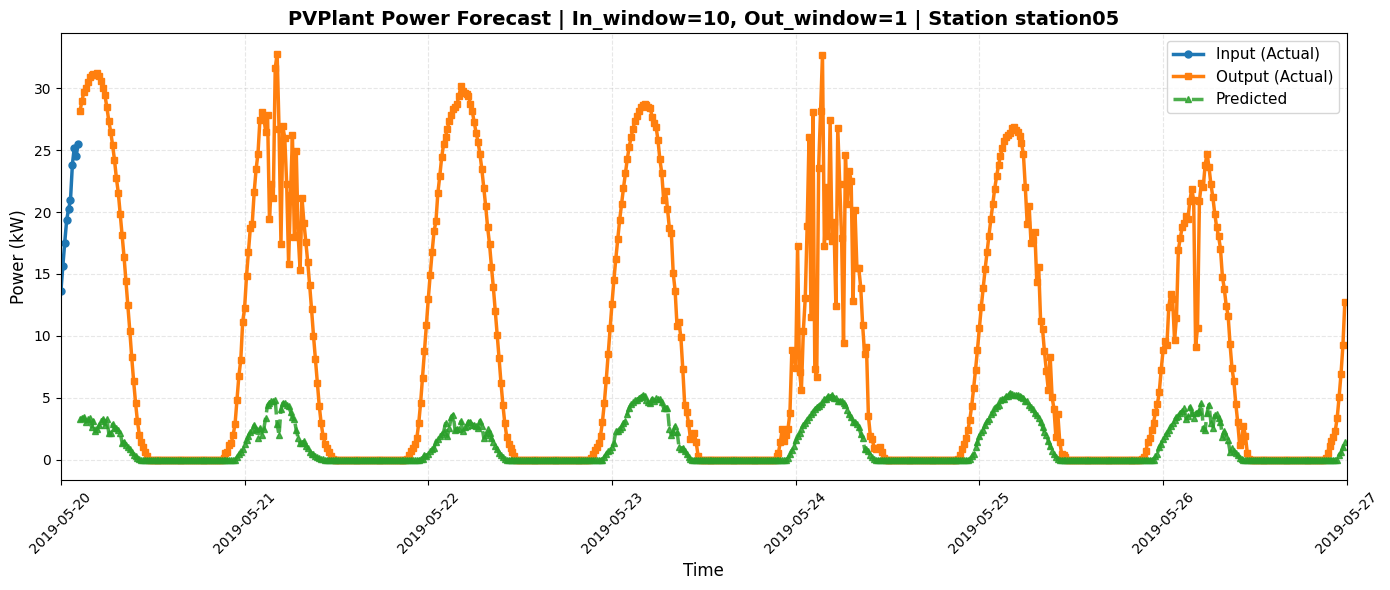

[저장] forecast_result_7_lstm_station06_station06.png


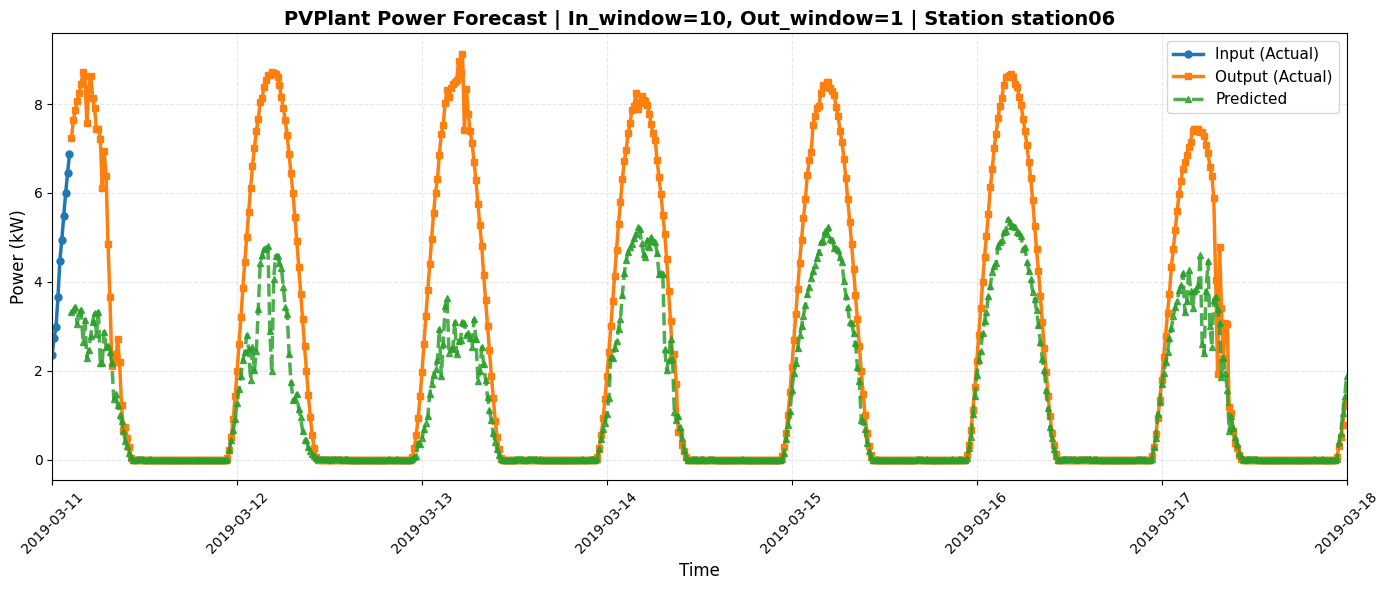

[저장] forecast_result_7_lstm_station07_station07.png


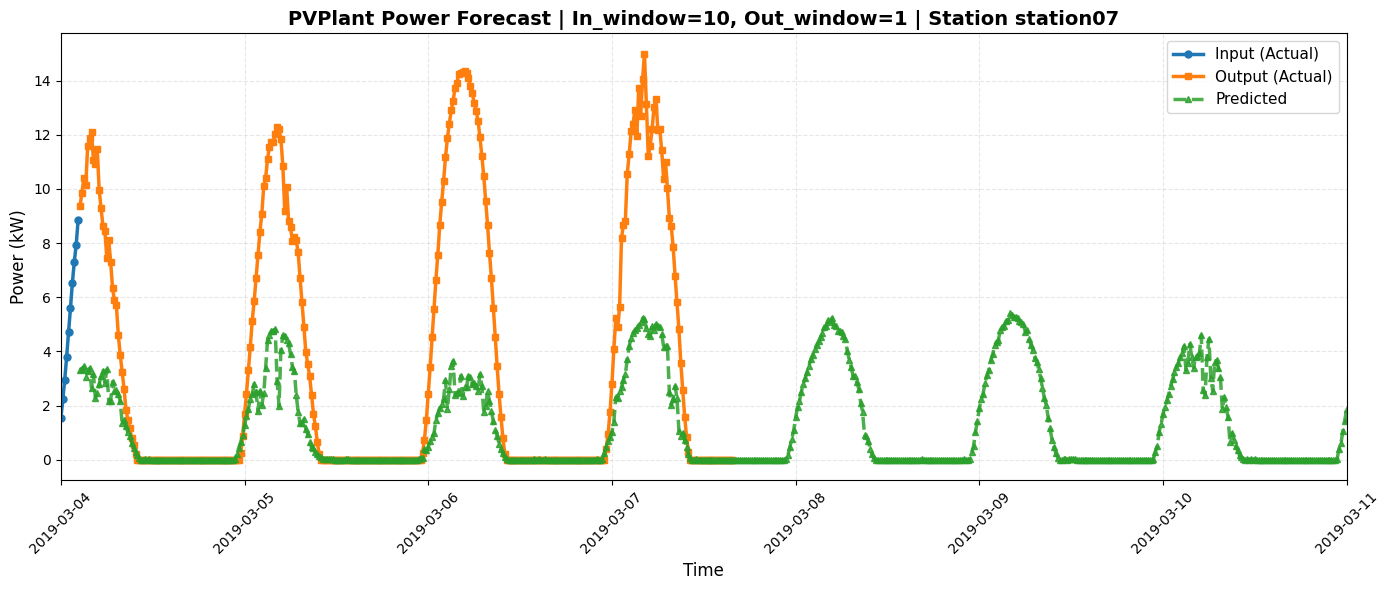

[저장] forecast_result_7_lstm_station08_station08.png


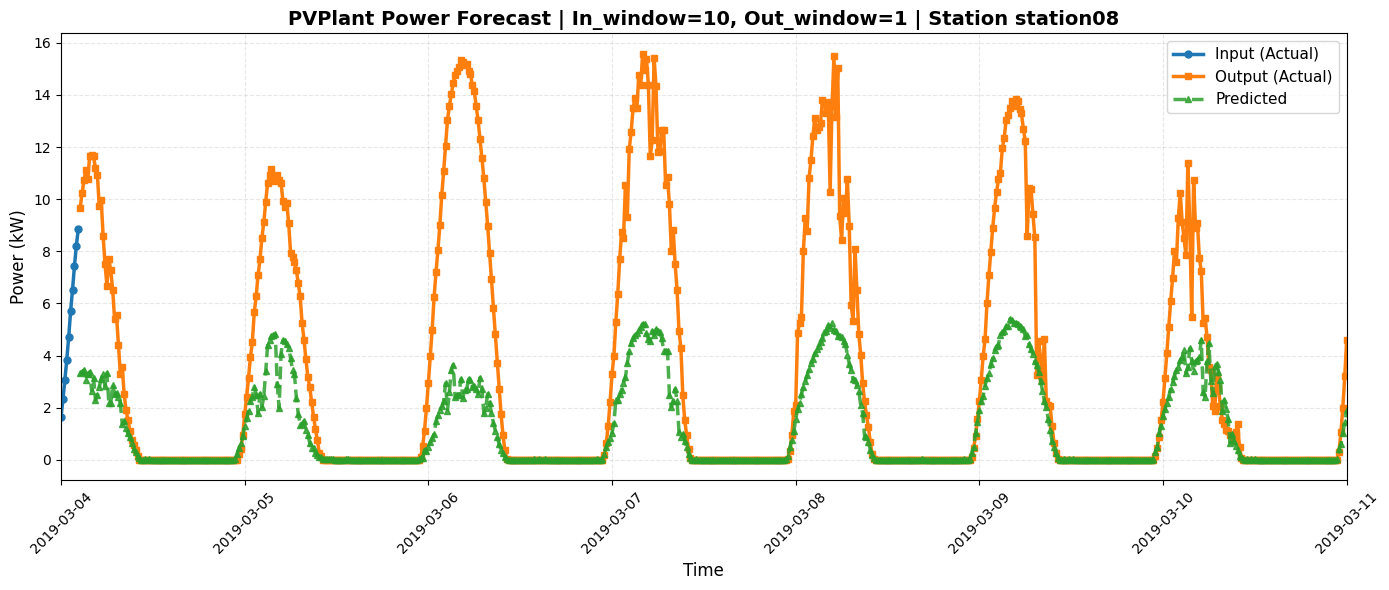

[저장] forecast_result_7_lstm_station09_station09.png


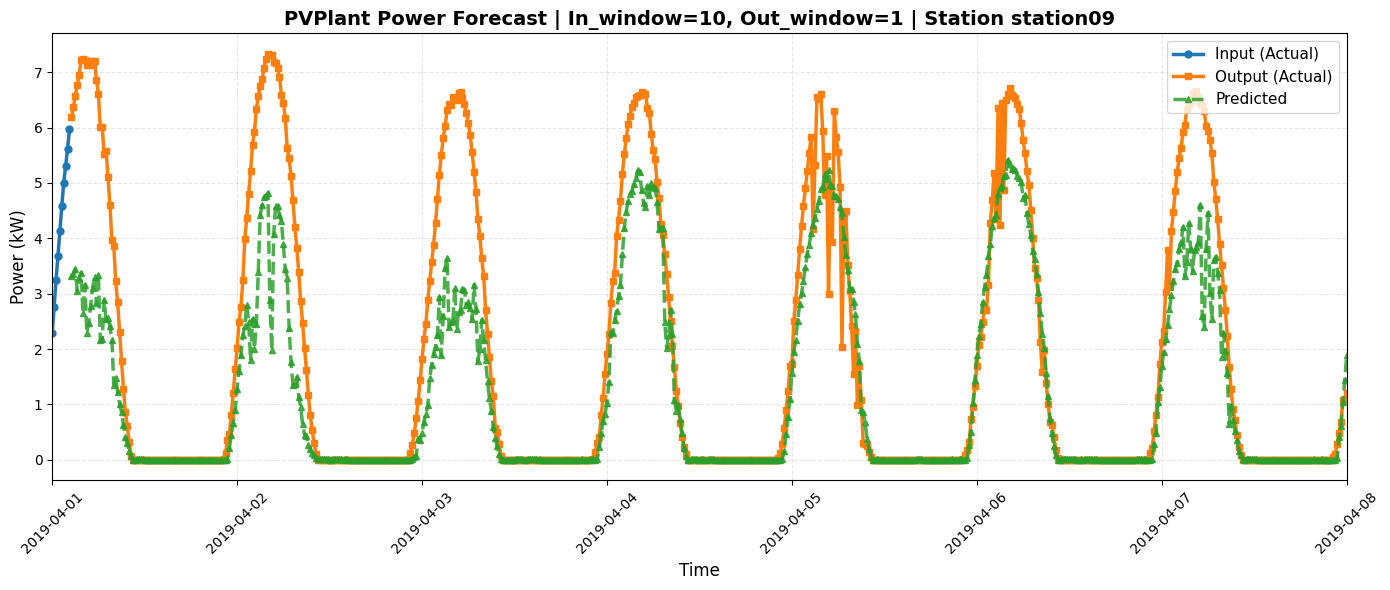

In [131]:
station_list = stations["Station_ID"].astype(str).unique().tolist()

for sid in station_list:
    plot_single_station_predictions_2days(
        model=best_lstm,
        valid_loader=valid_loader,   # 가능하면 이 Loader도 해당 sid만 포함되게 준비하면 가장 안전
        valid_df=valid_df,
        device=torch.device('cuda'),
        input_len=10,
        output_len=1,
        start_idx=0,
        y_scaler=y_scaler,
        logged=True,
        station_id=sid,              # 단일 문자열만 전달
        view_days=7,
        save_path=f'forecast_result_7_lstm_{sid}.png'
    )

In [72]:
plot_station_2days_forecast(
    model=best_transformer,
    valid_loader=valid_loader,
    valid_df=valid_df,
    device=torch.device('cuda'),
    input_len=10,
    output_len=1,
    start_idx=0,
    y_scaler=y_scaler,
    log_target=True,
    station_id=station_list,
    view_days=7,
    save_path='forecast_result_7_transformer.png'
)


NameError: name 'plot_station_2days_forecast' is not defined

## END